In [1]:
import lxml
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree
import gzip

# Paths

In [2]:
# Output Files path
output_path = r'output/specificCarrierReceiverShapleyExample/'
if not os.path.exists(output_path):
    raise Exception("Output path does not exist: " + output_path)
else:
    print(os.listdir(output_path))

# List of run instance folders
run_instance_folders = filter(lambda x: "-200" in x and "0.01p" in x, os.listdir(output_path))
run_instance_folders = sorted(run_instance_folders)
print("Run instance folders:", run_instance_folders)

['penSweep-af0.75-p0.003-proportional', 'penSweep-af0.60-p0.005-exactShapley', 'penSweep-af0.60-p0.050-exactShapley', 'penSweep-af0.60-p0.050-approxShapMC', 'penSweep-af0.60-p0.005-approxShapMC', 'penSweep-af0.60-p0.050-approxShapStrat', 'penSweep-af0.75-p0.003-marginal', 'penSweep-af0.90-p0.050-approxShapStrat', 'penSweep-af0.75-p0.020-approxShapStrat', 'penSweep-af0.60-p0.000-marginal', 'penSweep-af0.60-p0.045-approxShapMC', 'penSweep-af0.60-p0.010-approxShapMC', 'penSweep-af0.60-p0.010-exactShapley', '0.9a-0.01p-100-approxShapleyStratifiedCheck', 'penSweep-af0.60-p0.045-exactShapley', 'penSweep-af0.75-p0.020-proportional', 'penSweep-af0.60-p0.035-marginal', 'penSweep-af0.90-p0.045-approxShapMC', 'penSweep-af0.90-p0.010-approxShapMC', 'penSweep-af0.90-p0.010-exactShapley', 'penSweep-af0.90-p0.045-exactShapley', 'allocSweep-af0.55-p0.010-exactShapley', 'penSweep-af0.75-p0.040-marginal', 'allocSweep-af0.55-p0.010-approxShapMC', 'allocSweep-af0.95-p0.010-marginal', 'allocSweep-af0.95-p0

# Utils

## Count collaborative receivers

In [3]:
def count_collaborative_receivers(receiver_file_path, original_tw=(6, 8)):
    """
    Count collaborative receivers from a receiver XML file.
    
    Parameters:
    -----------
    receiver_file_path : str
        Path to the receivers.xml.gz file
    original_tw : tuple
        Original time window as (start_hour, end_hour), default is (6, 8)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'collaborative_receivers': list of collaborative receiver details
        - 'non_collaborative_receivers': list of non-collaborative receiver details
        - 'count_collaborative': count of collaborative receivers
        - 'count_non_collaborative': count of non-collaborative receivers
    """
    from lxml import etree
    import gzip
    
    # Lists to store receiver information
    collaborative_receivers = []
    non_collaborative_receivers = []
    
    # Parse the XML file
    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Iterate through all receivers
    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        
        # Find the selected plan
        selected_plan = receiver.find('.//plan[@selected="yes"]')
        
        if selected_plan is not None:
            # Get the score
            score = float(selected_plan.get('score', -9999999))
            
            # Get the time window
            time_window = selected_plan.find('timeWindow')
            
            if time_window is not None:
                # Parse start and end times (format: "HH:MM:SS")
                start_time = time_window.get('start')
                end_time = time_window.get('end')
                
                # Convert to hours for comparison
                start_hour = int(start_time.split(':')[0])
                end_hour = int(end_time.split(':')[0])
                
                receiver_info = {
                    'id': receiver_id,
                    'time_window': (start_hour, end_hour),
                    'time_window_str': f"{start_time} - {end_time}",
                    'score': score
                }
                
                # Check if time window is different from original_tw
                if (start_hour, end_hour) == original_tw:
                    non_collaborative_receivers.append(receiver_info)
                else:
                    collaborative_receivers.append(receiver_info)
    total_score = 0
    for receiver in collaborative_receivers + non_collaborative_receivers:
        total_score += receiver['score']

    return {
        'collaborative_receivers': collaborative_receivers,
        'non_collaborative_receivers': non_collaborative_receivers,
        'count_collaborative': len(collaborative_receivers),
        'count_non_collaborative': len(non_collaborative_receivers),
        'total_receivers': len(collaborative_receivers) + len(non_collaborative_receivers),
        'total_score': total_score
    }

In [4]:
''' 
Plot the relationship between collaborative receivers/total scores and set factor.
    It needs a dictionary with the key as penalty value-like strings 
    and the value as the proportion of collaborative receivers.
    It will share the x-axis as penalty values, 
    and the left y-axis as the proportion of collaborative receivers; 
    the right y-axis as the total scores of all receivers.
'''
def plot_collaboration_stat(factor_type: str,
                            prop_collaborators_dict: dict, 
                            stat_total_scores_dict: dict,
                            output_path: str = None):
    if factor_type.lower() not in ['penalty', 'allocation']:
        raise ValueError("factor_type must be either 'penalty' or 'allocation'")
    if factor_type.lower() == 'penalty':
        x_label = 'Penalty Value (per second)'
        title = 'Collaboration Proportion and Total Scores with Penalty Values'
        file_name = 'collaboration_with_penalty.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'p' in y, x.split("-")))[0].replace("p", ""), factor))
        # factor = sorted(factor)
    else:
        x_label = 'Allocation Factor'
        title = 'Collaboration Proportion and Total Scores with Allocation Factors'
        file_name = 'collaboration_with_allocation.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'a' in y, x.split("-")))[0].replace("a", ""), factor))
        # factor = sorted(factor)
        
    factor = list(map(lambda x: float(x), factor))
    # Sort the factor and corresponding values
    sorted_indices = np.argsort(factor)
    factor = [factor[i] for i in sorted_indices]
    prop_collaborators_dict = {list(prop_collaborators_dict.keys())[i]: list(prop_collaborators_dict.values())[i] for i in sorted_indices}
    stat_total_scores_dict = {list(stat_total_scores_dict.keys())[i]: list(stat_total_scores_dict.values())[i] for i in sorted_indices}
    proportions = list(prop_collaborators_dict.values())
    total_scores = list(stat_total_scores_dict.values())

    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Proportion of Collaborative Receivers', color=color)
    ax1.plot(factor, proportions, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xticks(factor)
    ax1.set_xticklabels([str(p) for p in factor])

    # Set the orientation of the x tick labels to vertical
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Total Scores of All Receivers', color=color)
    ax2.plot(factor, total_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(min(total_scores) - 0.1*abs(min(total_scores)), max(total_scores) + 0.1*abs(max(total_scores)))
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.title(title)
    plt.grid(True)

    if output_path:
        plt.savefig(os.path.join(output_path, file_name))

# Main

Analyzing run instance folder: 0.45a-0.01p-200
Analyzing run instance folder: 0.4a-0.01p-200
Analyzing run instance folder: 0.55a-0.01p-200
Analyzing run instance folder: 0.5a-0.01p-200
Analyzing run instance folder: 0.65a-0.01p-200
Analyzing run instance folder: 0.6a-0.01p-200
Analyzing run instance folder: 0.75a-0.01p-200
Analyzing run instance folder: 0.7a-0.01p-200
Analyzing run instance folder: 0.85a-0.01p-200
Analyzing run instance folder: 0.8a-0.01p-200
Analyzing run instance folder: 0.95a-0.01p-200
Analyzing run instance folder: 0.9a-0.01p-200
Analyzing run instance folder: 1.0a-0.01p-200


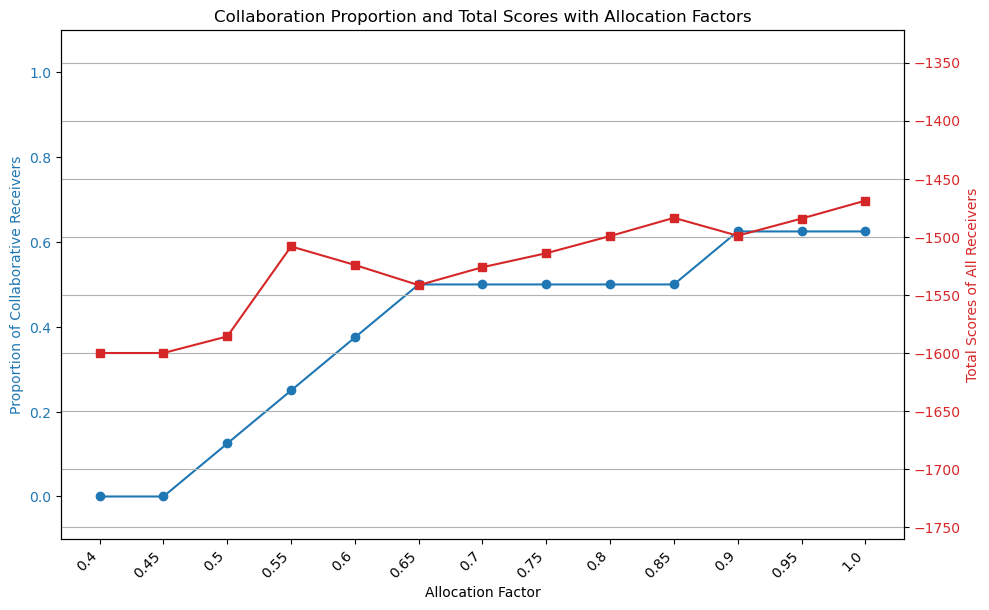

In [103]:
original_tw = (6, 8) 
detail_results = {}
stat_scores = {}
stat_count_collaboration_receivers = {}
stat_prop_collaboration_receivers = {}
for run_folder in run_instance_folders:
    print(f"Analyzing run instance folder: {run_folder}")
    receiver_file_path = os.path.join(output_path, run_folder, 'receivers.xml.gz')
    if not os.path.exists(receiver_file_path):
        raise Exception("Missing receiver file.")
    
     # Original time window
    result = count_collaborative_receivers(receiver_file_path, original_tw)
    
    # Store results
    detail_results[run_folder] = result
    stat_scores[run_folder] = result['total_score']
    stat_count_collaboration_receivers[run_folder] = result['count_collaborative']
    stat_prop_collaboration_receivers[run_folder] = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0

# plot_collaboration_stat(factor_type='penalty',
#                         prop_collaborators_dict=stat_prop_collaboration_receivers,
#                         stat_total_scores_dict=stat_scores,
#                         output_path=None)
plot_collaboration_stat(factor_type='allocation',
                        prop_collaborators_dict=stat_prop_collaboration_receivers,
                        stat_total_scores_dict=stat_scores,
                        output_path=None)

In [44]:
stat_scores

{'0.001-200': -1346.3733180219074,
 '0.003-200': -1403.1865585797973,
 '0.005-200': -1442.14382250386,
 '0.01-200': -1504.1314816,
 '0.02-200': -1538.3325508,
 '0.03-200': -1548.1008899522453,
 '0.035-200': -1600.0,
 '0.04-200': -1600.0,
 '0.05-200': -1600.0}

# Main for various penalty and allocation factors

In [31]:
sa_kw = ['allocSweep', 'penSweep']

# Define allocation methods
ALLOCATION_METHODS = ['exactShapley', 'marginal', 'proportional', 'approxShapMC', 'approxShapStrat']
METHOD_LABELS = {
    'exactShapley': 'Exact Shapley',
    'marginal': 'Marginal',
    'proportional': 'Proportional',
    'approxShapMC': 'Approx Shapley (MC)',
    'approxShapStrat': 'Approx Shapley (Stratified)'
}

def parse_folder_name(folder_name):
    """
    Parse folder name to extract allocation factor, penalty, and method.
    Example: 'allocSweep-af0.40-p0.010-exactShapley' -> (0.40, 0.010, 'exactShapley')
    """
    parts = folder_name.split('-')
    af = float(parts[1].replace('af', ''))
    p = float(parts[2].replace('p', ''))
    method = parts[3]
    return af, p, method

In [32]:
alloc_folders = list(filter(lambda x: sa_kw[0] in x, os.listdir(output_path)))
pen_folders = list(filter(lambda x: sa_kw[1] in x, os.listdir(output_path)))

In [33]:
def get_carrier_final_score(folder_path):
    """
    Get the final iteration's carrier score from carrier_scores.txt file.
    
    Parameters:
    -----------
    folder_path : str
        Path to the run instance folder
    
    Returns:
    --------
    float : The final carrier score (avg. EXECUTED from last iteration)
    """
    score_file = os.path.join(folder_path, 'carrier_scores.txt')
    if not os.path.exists(score_file):
        return None
    
    with open(score_file, 'r') as f:
        lines = f.readlines()
    
    # Get the last line (final iteration)
    if len(lines) > 1:
        last_line = lines[-1].strip()
        parts = last_line.split('\t')
        if len(parts) >= 2:
            return float(parts[1])  # avg. EXECUTED score
    return None


def collect_sweep_data(folders, output_path, original_tw=(6, 8)):
    """
    Collect collaboration statistics from sweep folders.
    
    Returns:
    --------
    pandas.DataFrame with columns: folder, af, penalty, method, count_collaborative, 
                                   count_non_collaborative, total_receivers, prop_collaborative, 
                                   total_score (receiver), carrier_score, combined_score
    """
    data = []
    for folder in folders:
        af, penalty, method = parse_folder_name(folder)
        folder_path = os.path.join(output_path, folder)
        receiver_file_path = os.path.join(folder_path, 'receivers.xml.gz')
        
        if os.path.exists(receiver_file_path):
            result = count_collaborative_receivers(receiver_file_path, original_tw)
            prop_collaborative = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0
            
            # Get carrier score
            carrier_score = get_carrier_final_score(folder_path)
            combined_score = result['total_score'] + (carrier_score if carrier_score else 0)
            
            data.append({
                'folder': folder,
                'af': af,
                'penalty': penalty,
                'method': method,
                'count_collaborative': result['count_collaborative'],
                'count_non_collaborative': result['count_non_collaborative'],
                'total_receivers': result['total_receivers'],
                'prop_collaborative': prop_collaborative,
                'receiver_score': result['total_score'],
                'carrier_score': carrier_score,
                'combined_score': combined_score
            })
        else:
            print(f"Warning: File not found - {receiver_file_path}")
    
    return pd.DataFrame(data)

In [34]:
def plot_allocation_sweep(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis: 
    One graph with 5 lines (one per method) showing how collaboration proportion 
    changes with allocation factor (penalty fixed).
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    for method in ALLOCATION_METHODS:
        method_df = df[df['method'] == method].sort_values('af')
        if not method_df.empty:
            ax.plot(method_df['af'], method_df['prop_collaborative'], 
                   marker=markers[method], color=colors[method], 
                   label=METHOD_LABELS[method], linewidth=2, markersize=8)
    
    ax.set_xlabel('Allocation Factor', fontsize=12)
    ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=12)
    ax.set_title('Sensitivity Analysis: Allocation Factor vs Collaboration\n(Penalty Fixed at 0.01)', fontsize=14)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_factor.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_separate(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis with each method in a separate subplot.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method].sort_values('af')
        if not method_df.empty:
            ax.plot(method_df['af'], method_df['prop_collaborative'], 
                   marker='o', color=colors[method], linewidth=2, markersize=6)
            ax.fill_between(method_df['af'], method_df['prop_collaborative'], alpha=0.3, color=colors[method])
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Prop. Collaborative', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide the unused subplot
    axes[-1].axis('off')
    
    fig.suptitle('Sensitivity Analysis: Allocation Factor vs Collaboration (by Method)\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_factor_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_scores(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis for scores:
    One graph with all methods showing receiver scores, carrier scores, and combined scores.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score (Receiver + Carrier)')]
    
    for ax_idx, (score_col, score_label) in enumerate(score_types):
        ax = axes[ax_idx]
        for method in ALLOCATION_METHODS:
            method_df = df[df['method'] == method].sort_values('af')
            if not method_df.empty and score_col in method_df.columns:
                ax.plot(method_df['af'], method_df[score_col], 
                       marker=markers[method], color=colors[method], 
                       label=METHOD_LABELS[method], linewidth=2, markersize=6)
        
        ax.set_xlabel('Allocation Factor', fontsize=11)
        ax.set_ylabel(score_label, fontsize=11)
        ax.set_title(f'{score_label}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    
    fig.suptitle('Score Sensitivity Analysis: Allocation Factor\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_allocation_sweep_scores_separate(df, output_path=None):
    """
    Plot allocation factor sensitivity analysis for scores with each method in separate subplots.
    Each subplot shows receiver, carrier, and combined scores for one method.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_scores = {'receiver_score': '#1f77b4', 'carrier_score': '#ff7f0e', 'combined_score': '#2ca02c'}
    labels_scores = {'receiver_score': 'Receiver', 'carrier_score': 'Carrier', 'combined_score': 'Combined'}
    
    for idx, method in enumerate(ALLOCATION_METHODS):
        ax = axes[idx]
        method_df = df[df['method'] == method].sort_values('af')
        
        if not method_df.empty:
            for score_col, color in colors_scores.items():
                if score_col in method_df.columns:
                    ax.plot(method_df['af'], method_df[score_col], 
                           marker='o', color=color, linewidth=2, markersize=5,
                           label=labels_scores[score_col])
        
        ax.set_xlabel('Allocation Factor', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'{METHOD_LABELS[method]}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    
    axes[-1].axis('off')
    
    fig.suptitle('Score Sensitivity Analysis: Allocation Factor (by Method)\n(Penalty Fixed at 0.01)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_allocation_scores_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

In [35]:
def plot_penalty_sweep(df, output_path=None):
    """
    Plot penalty sensitivity analysis:
    3 graphs (one per allocation factor), each with 5 lines (one per method)
    showing how collaboration proportion changes with penalty value.
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    fig, axes = plt.subplots(1, len(allocation_factors), figsize=(6*len(allocation_factors), 6), sharey=True)
    if len(allocation_factors) == 1:
        axes = [axes]
    
    for idx, af in enumerate(allocation_factors):
        ax = axes[idx]
        af_df = df[df['af'] == af]
        
        for method in ALLOCATION_METHODS:
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            if not method_df.empty:
                ax.plot(method_df['penalty'], method_df['prop_collaborative'], 
                       marker=markers[method], color=colors[method], 
                       label=METHOD_LABELS[method], linewidth=2, markersize=6)
        
        ax.set_xlabel('Penalty Value (per second)', fontsize=11)
        if idx == 0:
            ax.set_ylabel('Proportion of Collaborative Receivers', fontsize=11)
        ax.set_title(f'Allocation Factor = {af}', fontsize=12)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        
        if idx == len(allocation_factors) - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
    
    fig.suptitle('Sensitivity Analysis: Penalty vs Collaboration\n(by Allocation Factor)', fontsize=14, y=1.02)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_separate(df, output_path=None):
    """
    Plot penalty sensitivity analysis with each method in a separate subplot grid.
    Creates a grid: rows = allocation factors, columns = methods
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    
    fig, axes = plt.subplots(len(allocation_factors), len(ALLOCATION_METHODS), 
                             figsize=(4*len(ALLOCATION_METHODS), 4*len(allocation_factors)), 
                             sharey=True, sharex=True)
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            
            if not method_df.empty:
                ax.plot(method_df['penalty'], method_df['prop_collaborative'], 
                       marker='o', color=colors[method], linewidth=2, markersize=5)
                ax.fill_between(method_df['penalty'], method_df['prop_collaborative'], 
                               alpha=0.3, color=colors[method])
            
            if row_idx == len(allocation_factors) - 1:
                ax.set_xlabel('Penalty', fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nProp. Collab.', fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            
            ax.set_ylim(-0.05, 1.05)
            ax.grid(True, alpha=0.3)
    
    fig.suptitle('Sensitivity Analysis: Penalty vs Collaboration\n(by Method and Allocation Factor)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_scores(df, output_path=None):
    """
    Plot penalty sensitivity analysis for scores:
    3 rows (allocation factors) x 3 cols (receiver, carrier, combined scores)
    Each subplot has 5 lines (methods)
    """
    allocation_factors = sorted(df['af'].unique())
    score_types = [('receiver_score', 'Receiver Score'), 
                   ('carrier_score', 'Carrier Score'), 
                   ('combined_score', 'Combined Score')]
    
    colors = {'exactShapley': '#1f77b4', 'marginal': '#ff7f0e', 'proportional': '#2ca02c', 
              'approxShapMC': '#d62728', 'approxShapStrat': '#9467bd'}
    markers = {'exactShapley': 'o', 'marginal': 's', 'proportional': '^', 
               'approxShapMC': 'D', 'approxShapStrat': 'v'}
    
    fig, axes = plt.subplots(len(allocation_factors), 3, 
                             figsize=(15, 5*len(allocation_factors)))
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, (score_col, score_label) in enumerate(score_types):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            
            for method in ALLOCATION_METHODS:
                method_df = af_df[af_df['method'] == method].sort_values('penalty')
                if not method_df.empty and score_col in method_df.columns:
                    ax.plot(method_df['penalty'], method_df[score_col], 
                           marker=markers[method], color=colors[method], 
                           label=METHOD_LABELS[method], linewidth=2, markersize=5)
            
            ax.set_xlabel('Penalty Value', fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nScore', fontsize=10)
            if row_idx == 0:
                ax.set_title(f'{score_label}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if row_idx == 0 and col_idx == 2:
                ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    
    fig.suptitle('Score Sensitivity Analysis: Penalty\n(by Allocation Factor)', fontsize=14)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_scores.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_penalty_sweep_scores_separate(df, output_path=None):
    """
    Plot penalty sensitivity analysis for scores with each method in separate subplots.
    Grid: rows = allocation factors, columns = methods
    Each subplot shows receiver, carrier, and combined scores for one method at one AF.
    """
    allocation_factors = sorted(df['af'].unique())
    
    colors_scores = {'receiver_score': '#1f77b4', 'carrier_score': '#ff7f0e', 'combined_score': '#2ca02c'}
    labels_scores = {'receiver_score': 'Receiver', 'carrier_score': 'Carrier', 'combined_score': 'Combined'}
    
    fig, axes = plt.subplots(len(allocation_factors), len(ALLOCATION_METHODS), 
                             figsize=(4*len(ALLOCATION_METHODS), 4*len(allocation_factors)))
    
    for row_idx, af in enumerate(allocation_factors):
        af_df = df[df['af'] == af]
        
        for col_idx, method in enumerate(ALLOCATION_METHODS):
            ax = axes[row_idx, col_idx] if len(allocation_factors) > 1 else axes[col_idx]
            method_df = af_df[af_df['method'] == method].sort_values('penalty')
            
            if not method_df.empty:
                for score_col, color in colors_scores.items():
                    if score_col in method_df.columns:
                        ax.plot(method_df['penalty'], method_df[score_col], 
                               marker='o', color=color, linewidth=2, markersize=4,
                               label=labels_scores[score_col] if row_idx == 0 and col_idx == 0 else None)
            
            if row_idx == len(allocation_factors) - 1:
                ax.set_xlabel('Penalty', fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f'AF={af}\nScore', fontsize=9)
            if row_idx == 0:
                ax.set_title(f'{METHOD_LABELS[method]}', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    # Add a single legend for all subplots
    handles = [plt.Line2D([0], [0], color=c, marker='o', linewidth=2) for c in colors_scores.values()]
    fig.legend(handles, labels_scores.values(), loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.02))
    
    fig.suptitle('Score Sensitivity Analysis: Penalty (by Method)\n', fontsize=14, y=1.05)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(os.path.join(output_path, 'sensitivity_penalty_scores_separate.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return fig

# Run Sensitivity Analysis

In [36]:
# Collect data from allocation sweep folders
print("Collecting data from allocation sweep folders...")
alloc_df = collect_sweep_data(alloc_folders, output_path)
print(f"Collected {len(alloc_df)} records from allocation sweep")
print(f"Allocation factors: {sorted(alloc_df['af'].unique())}")
print(f"Penalty values: {sorted(alloc_df['penalty'].unique())}")
print(f"Methods: {alloc_df['method'].unique().tolist()}")
alloc_df

Collected 60 records from allocation sweep
Allocation factors: [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Penalty values: [0.01]
Methods: ['exactShapley', 'approxShapMC', 'marginal', 'approxShapStrat', 'proportional']


,folder,af,penalty,method,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,allocSweep-af0.55-p0.010-exactShapley,0.55,0.01,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393
1,allocSweep-af0.55-p0.010-approxShapMC,0.55,0.01,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
2,allocSweep-af0.95-p0.010-marginal,0.95,0.01,marginal,0,8,8,0.000,-800.000000,392.142607,-407.857393
3,allocSweep-af0.95-p0.010-approxShapStrat,0.95,0.01,approxShapStrat,4,4,8,0.500,-652.958376,535.160565,-117.797811
4,allocSweep-af0.65-p0.010-approxShapStrat,0.65,0.01,approxShapStrat,3,5,8,0.375,-709.230605,637.468496,-71.762108
5,allocSweep-af0.50-p0.010-marginal,0.50,0.01,marginal,0,8,8,0.000,-800.000000,392.142607,-407.857393
6,allocSweep-af0.45-p0.010-proportional,0.45,0.01,proportional,0,8,8,0.000,-800.000000,392.142607,-407.857393
7,allocSweep-af0.50-p0.010-approxShapStrat,0.50,0.01,approxShapStrat,0,8,8,0.000,-800.000000,392.142607,-407.857393
8,allocSweep-af0.50-p0.010-approxShapMC,0.50,0.01,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
9,allocSweep-af0.50-p0.010-exactShapley,0.50,0.01,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393


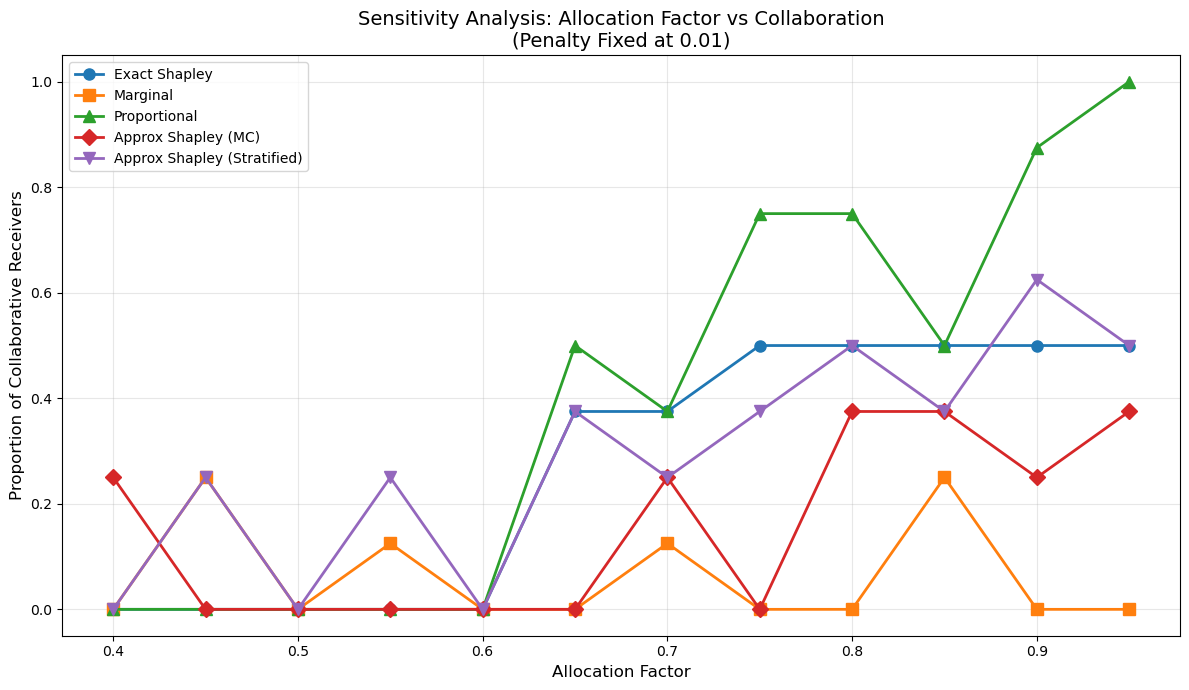

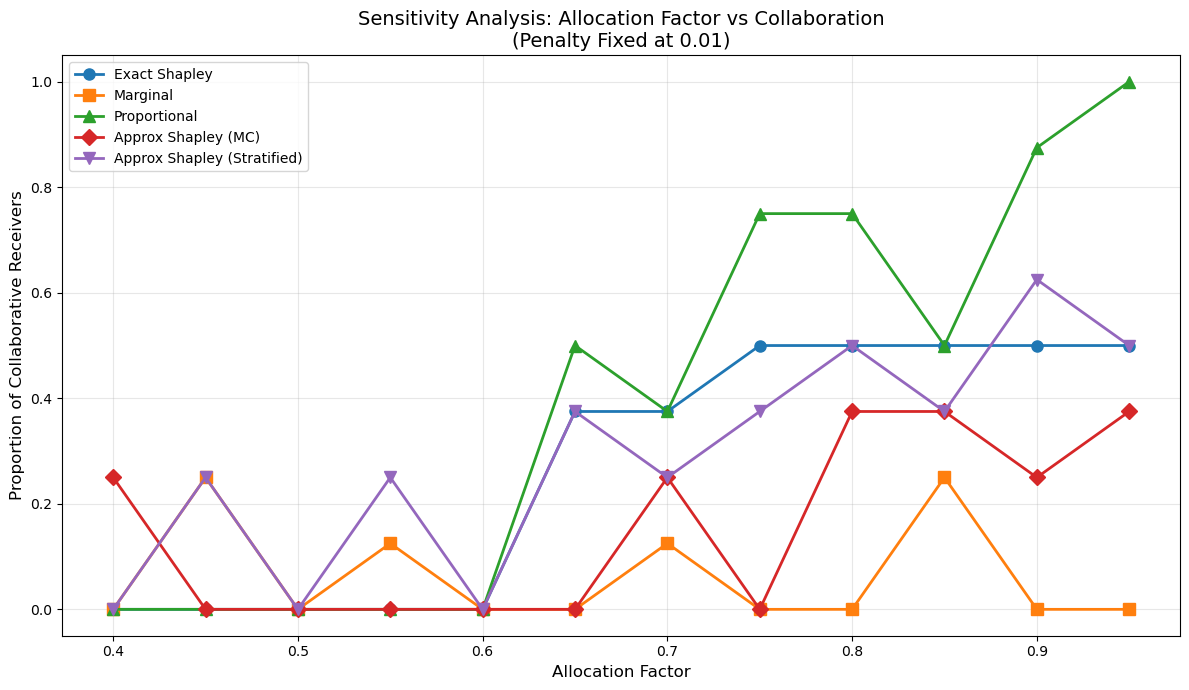

In [37]:
# Plot allocation factor sweep: Combined view (all methods in one graph)
plot_allocation_sweep(alloc_df, output_path=None)

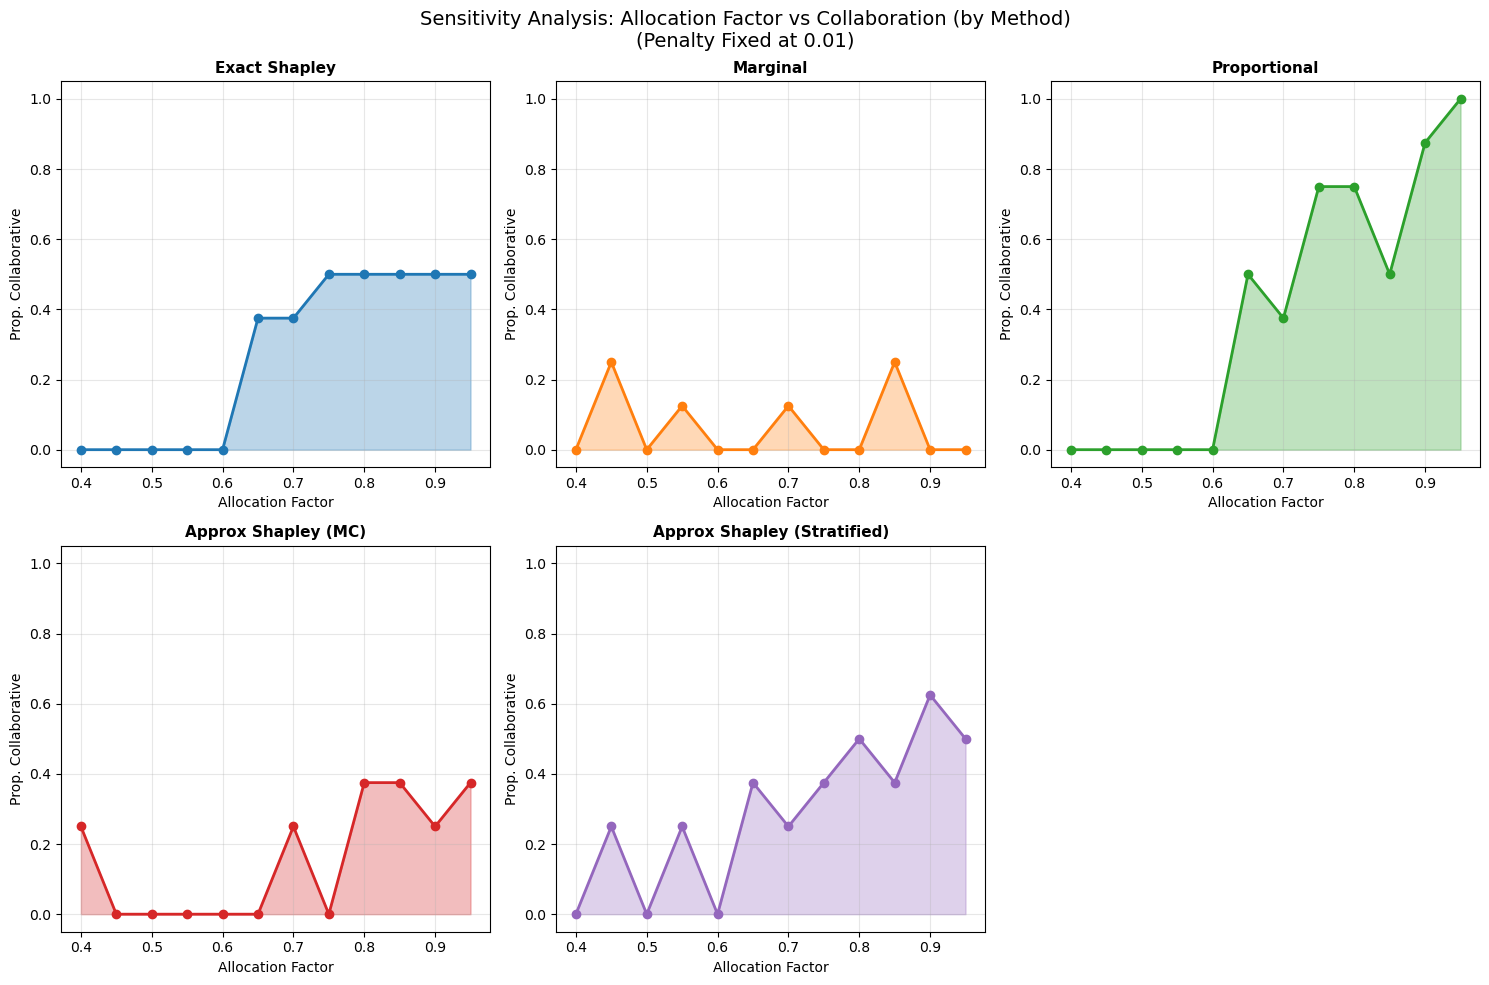

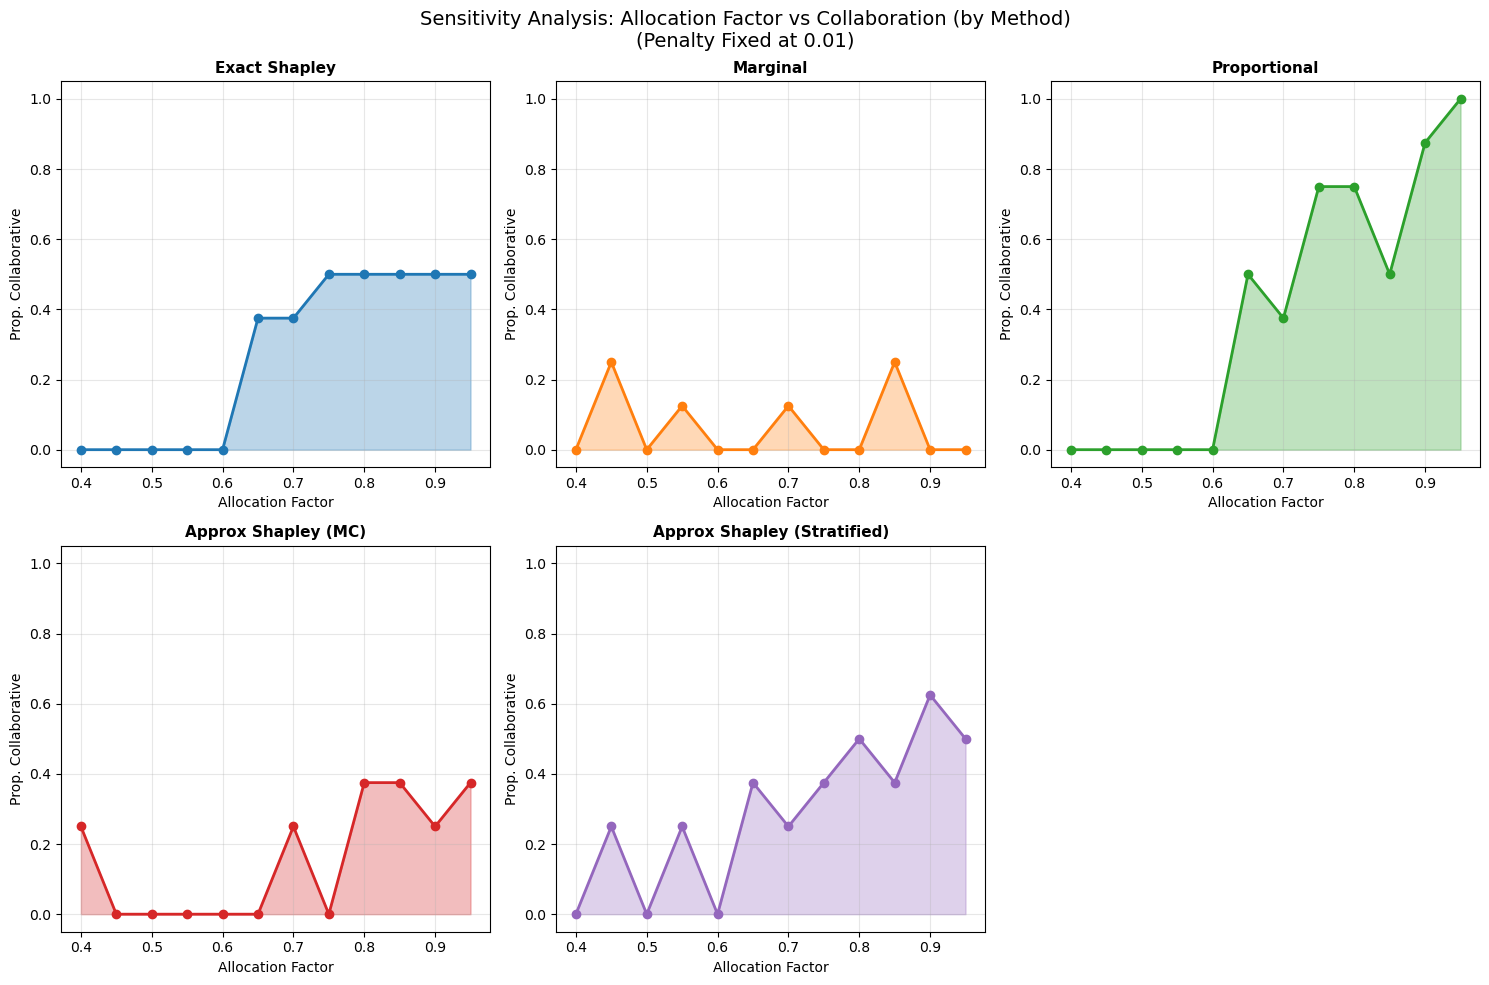

In [38]:
# Plot allocation factor sweep: Separate view (each method in its own subplot)
plot_allocation_sweep_separate(alloc_df, output_path=None)

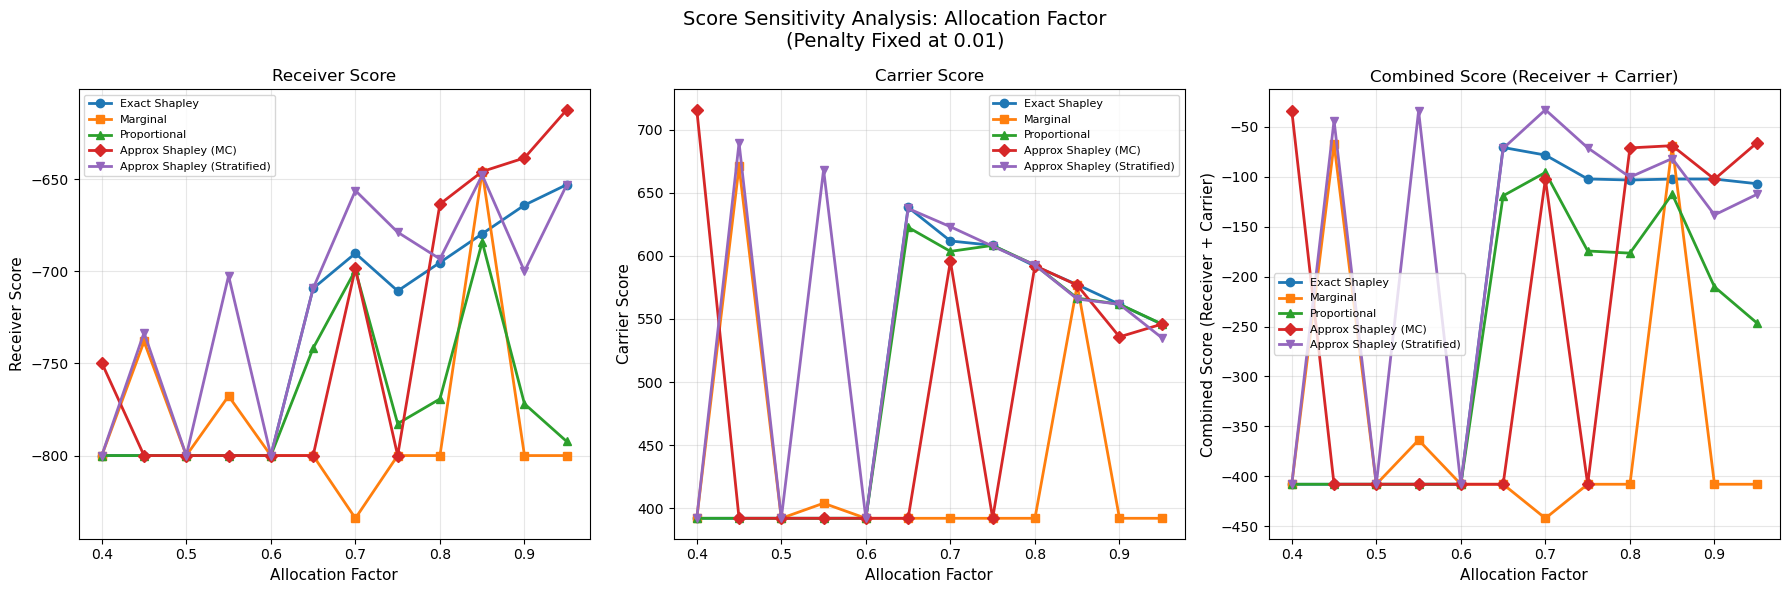

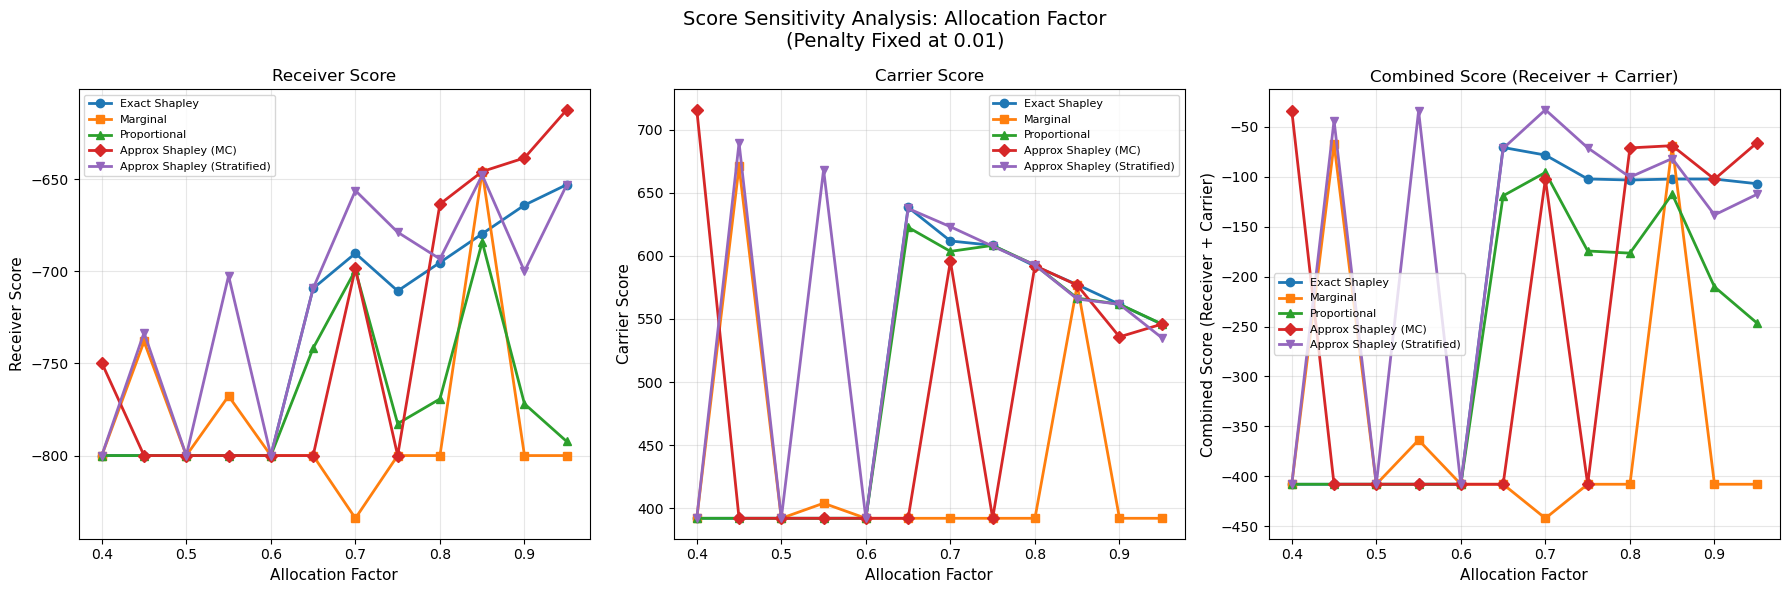

In [39]:
# Plot allocation factor sweep: Scores (receiver, carrier, combined) - All methods together
plot_allocation_sweep_scores(alloc_df, output_path=None)

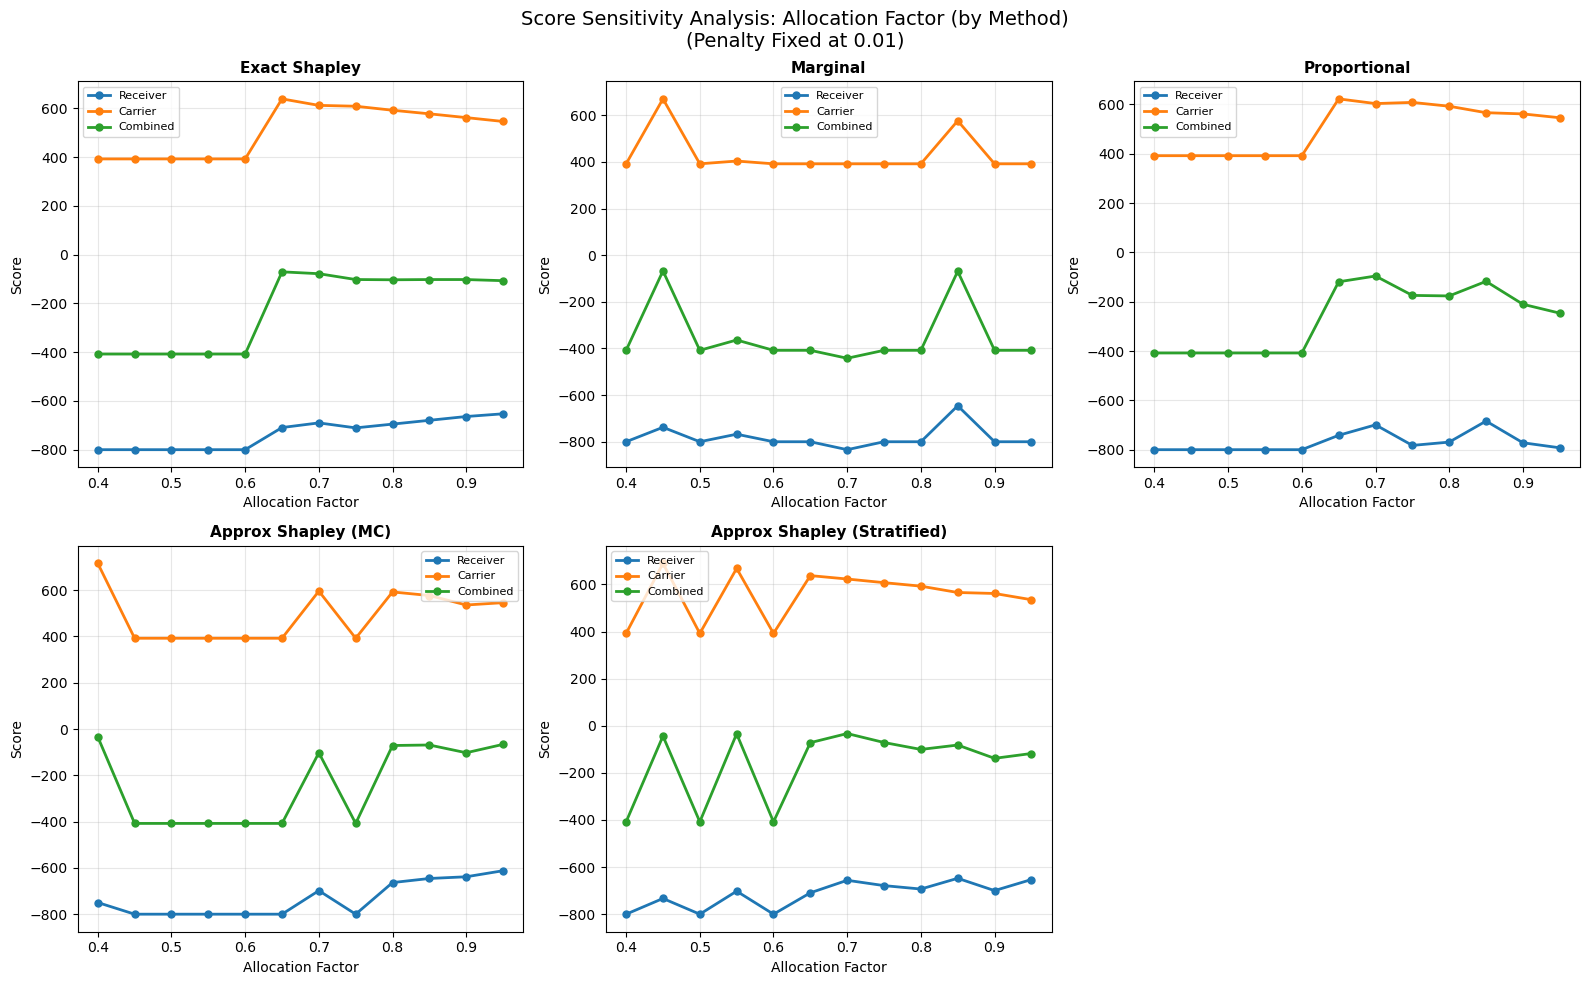

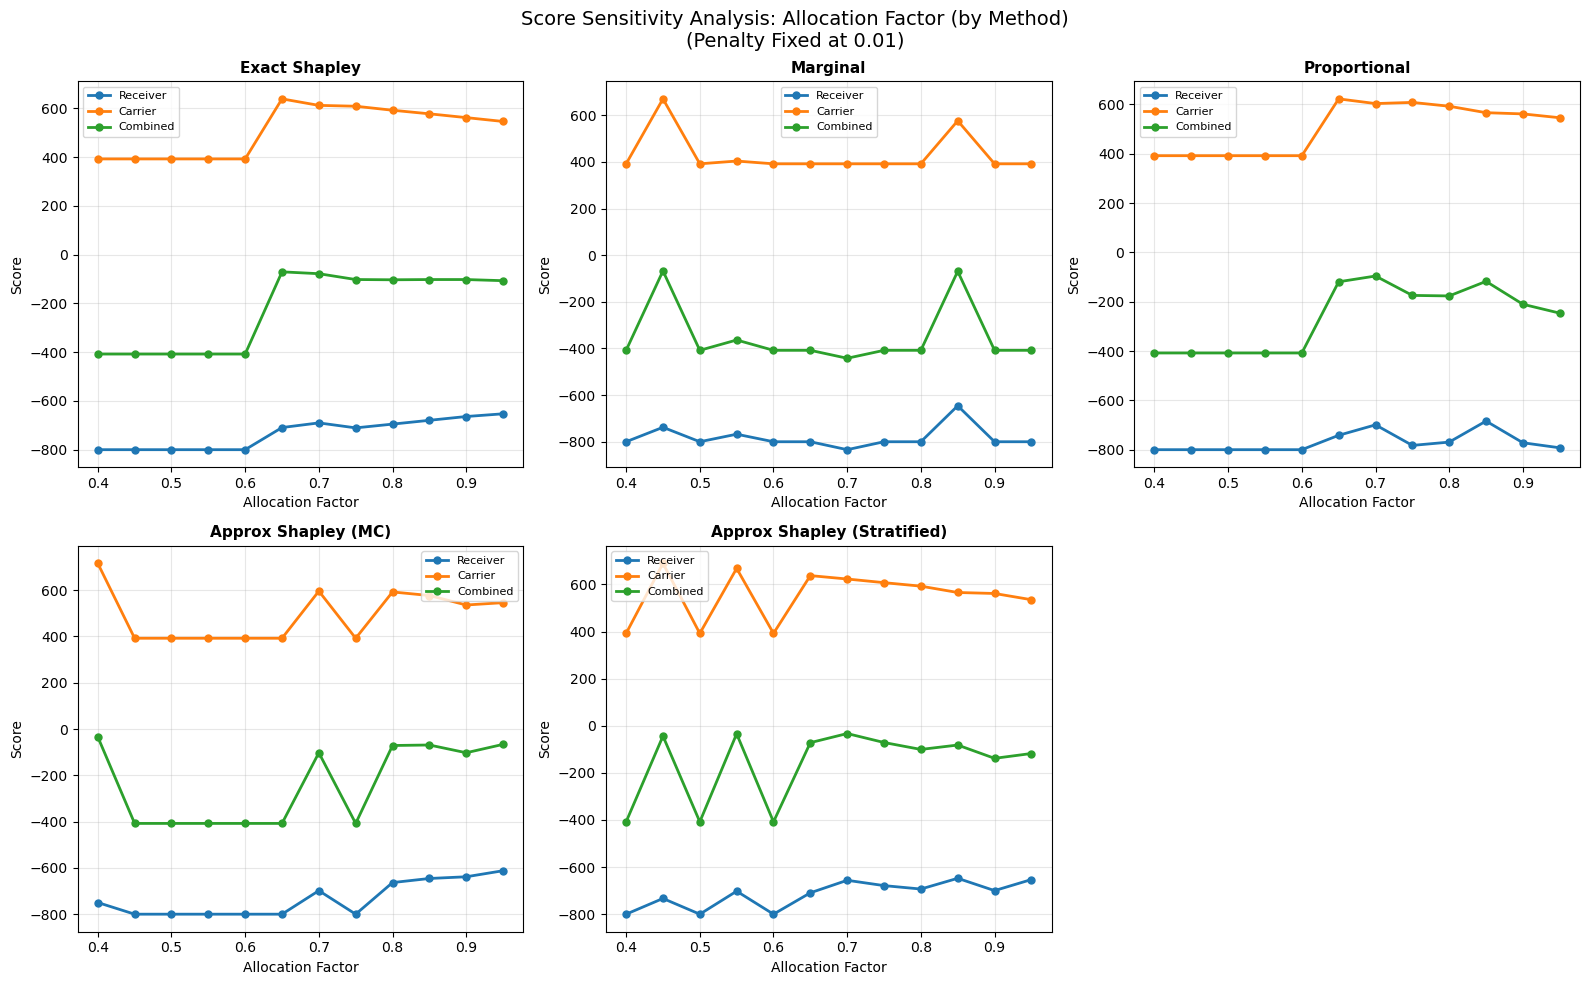

In [40]:
# Plot allocation factor sweep: Scores (receiver, carrier, combined) - Each method separate
plot_allocation_sweep_scores_separate(alloc_df, output_path=None)

In [45]:
# Collect data from penalty sweep folders
print("Collecting data from penalty sweep folders...")
pen_df = collect_sweep_data(pen_folders, output_path)
print(f"Collected {len(pen_df)} records from penalty sweep")
print(f"Allocation factors: {sorted(pen_df['af'].unique())}")
print(f"Penalty values: {sorted(pen_df['penalty'].unique())}")
print(f"Methods: {pen_df['method'].unique().tolist()}")
pen_df.head()

Collected 180 records from penalty sweep
Allocation factors: [0.6, 0.75, 0.9]
Penalty values: [0.0, 0.003, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
Methods: ['proportional', 'exactShapley', 'approxShapMC', 'approxShapStrat', 'marginal']
Collected 180 records from penalty sweep
Allocation factors: [0.6, 0.75, 0.9]
Penalty values: [0.0, 0.003, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
Methods: ['proportional', 'exactShapley', 'approxShapMC', 'approxShapStrat', 'marginal']


,folder,af,penalty,method,count_collaborative,count_non_collaborative,total_receivers,prop_collaborative,receiver_score,carrier_score,combined_score
0,penSweep-af0.75-p0.003-proportional,0.75,0.003,proportional,8,0,8,1.000,-653.063216,608.317496,-44.745720
1,penSweep-af0.60-p0.005-exactShapley,0.60,0.005,exactShapley,5,3,8,0.625,-703.234666,655.008830,-48.225837
2,penSweep-af0.60-p0.050-exactShapley,0.60,0.050,exactShapley,0,8,8,0.000,-800.000000,392.142607,-407.857393
3,penSweep-af0.60-p0.050-approxShapMC,0.60,0.050,approxShapMC,0,8,8,0.000,-800.000000,392.142607,-407.857393
4,penSweep-af0.60-p0.005-approxShapMC,0.60,0.005,approxShapMC,4,4,8,0.500,-724.412878,642.261808,-82.151070


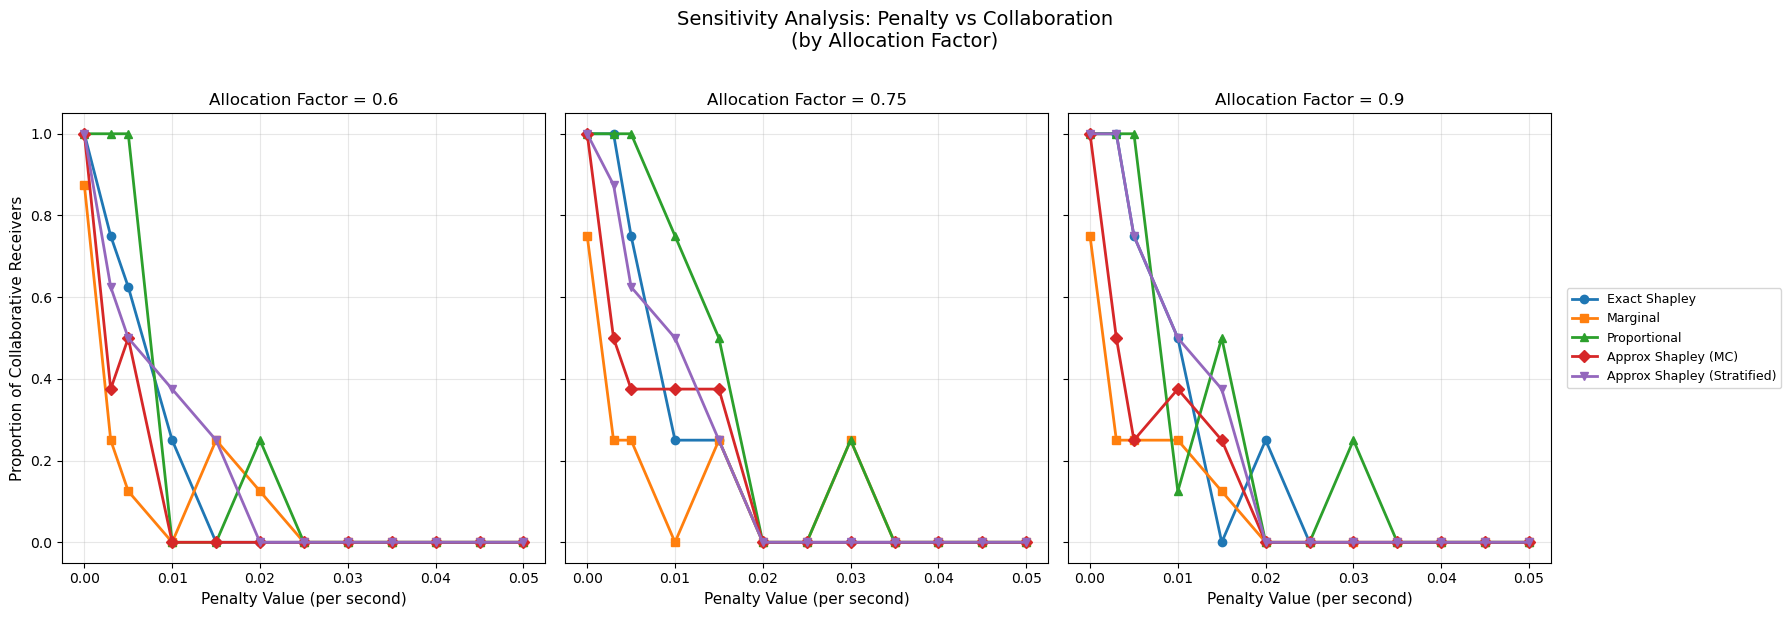

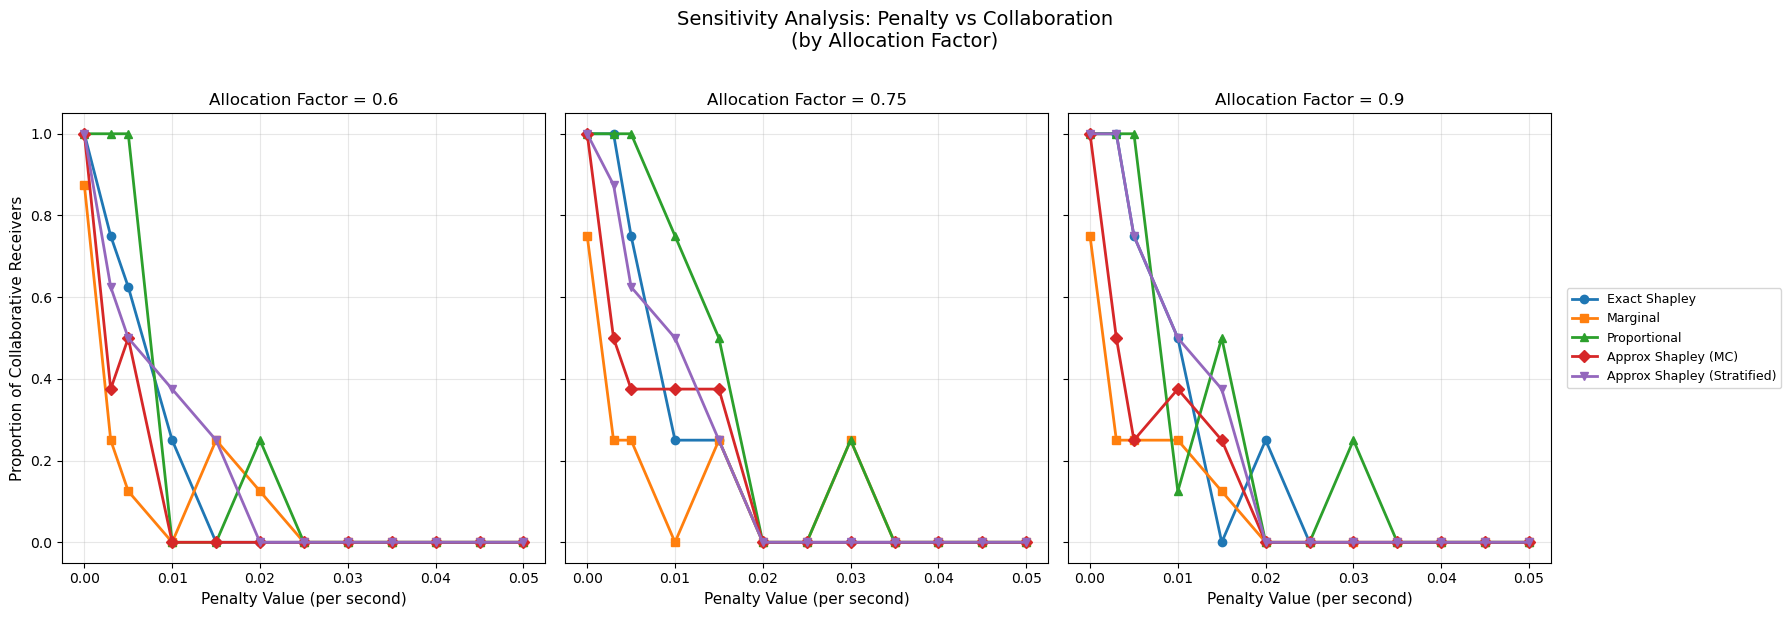

In [41]:
# Plot penalty sweep: Combined view (all methods in one graph per AF)
plot_penalty_sweep(pen_df, output_path=None)

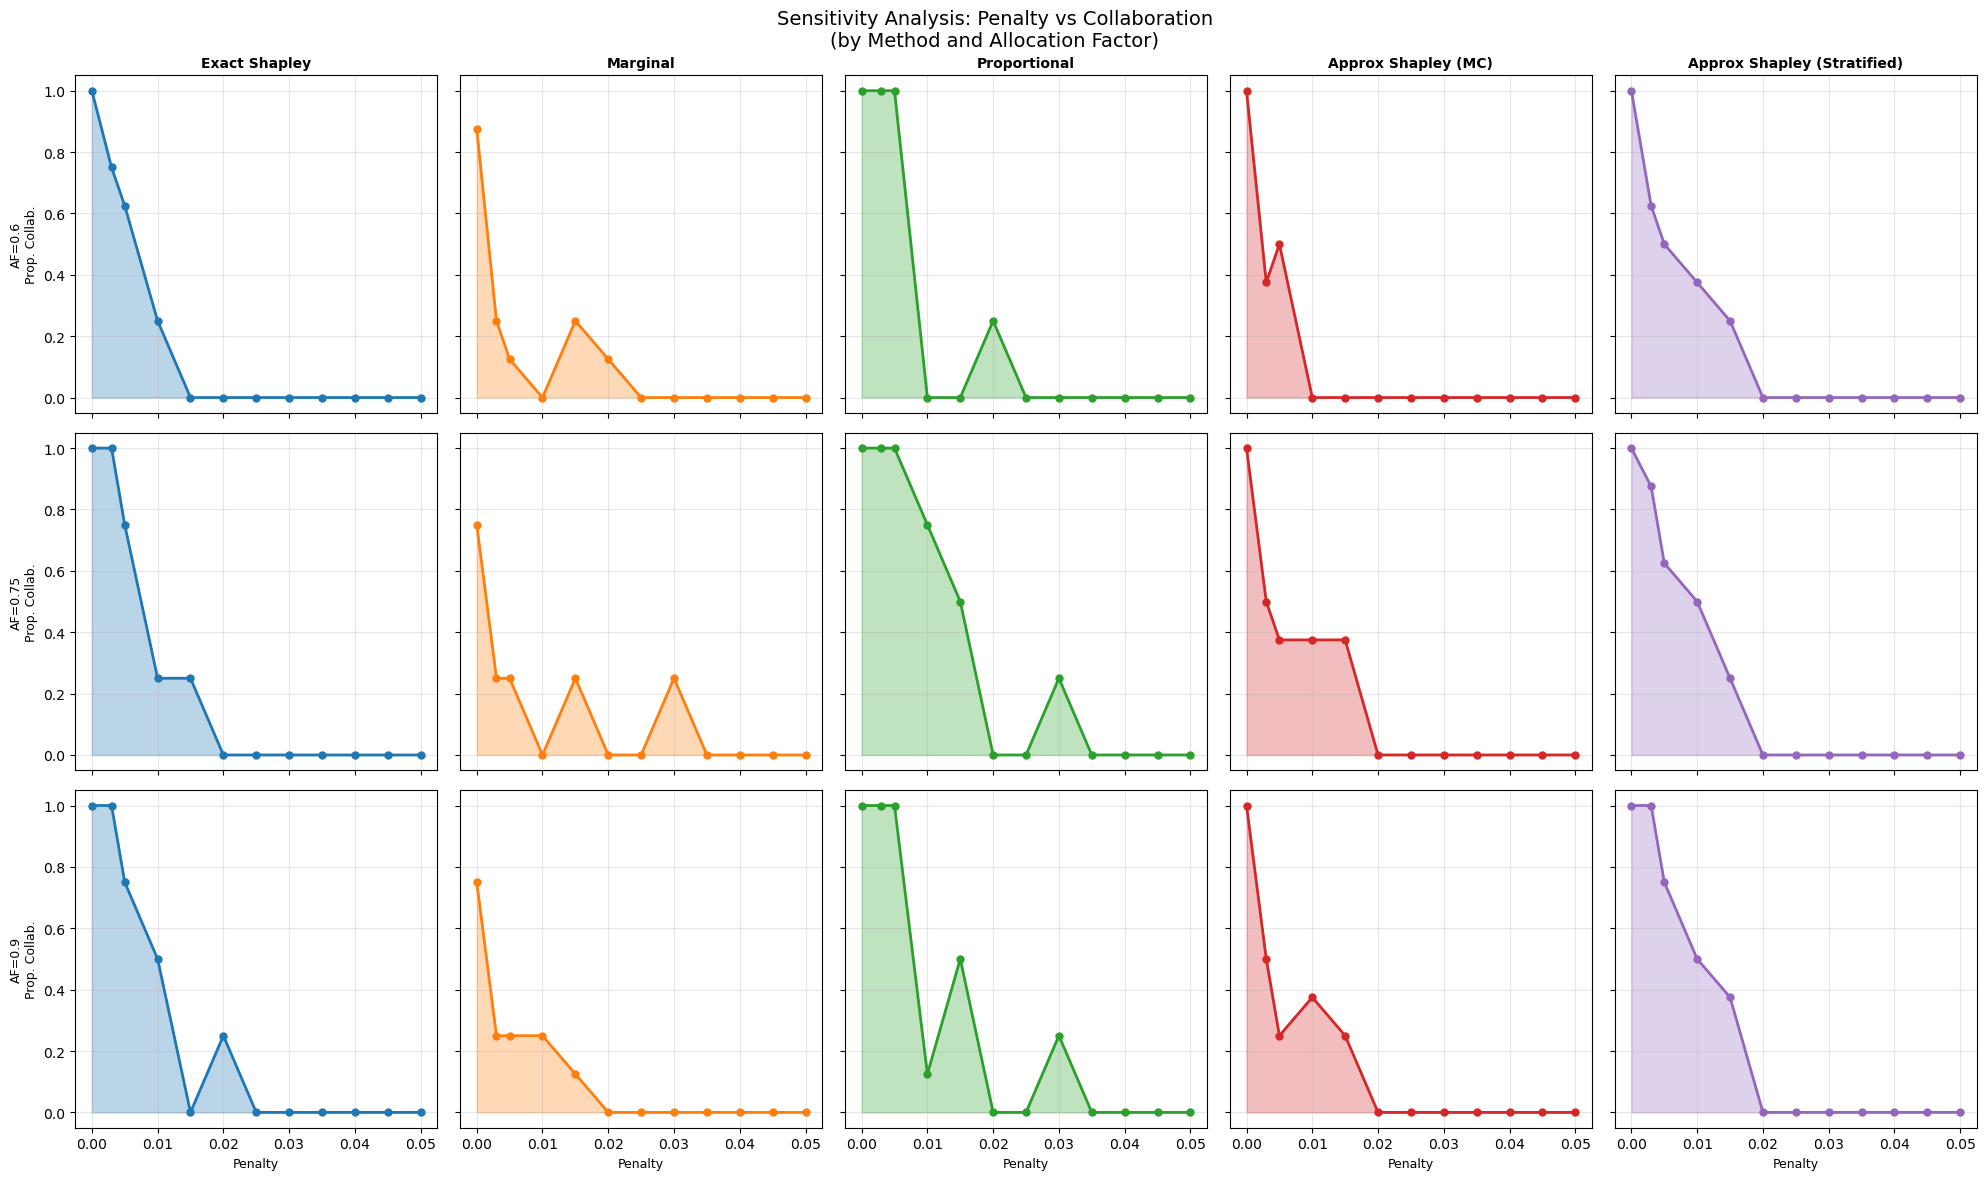

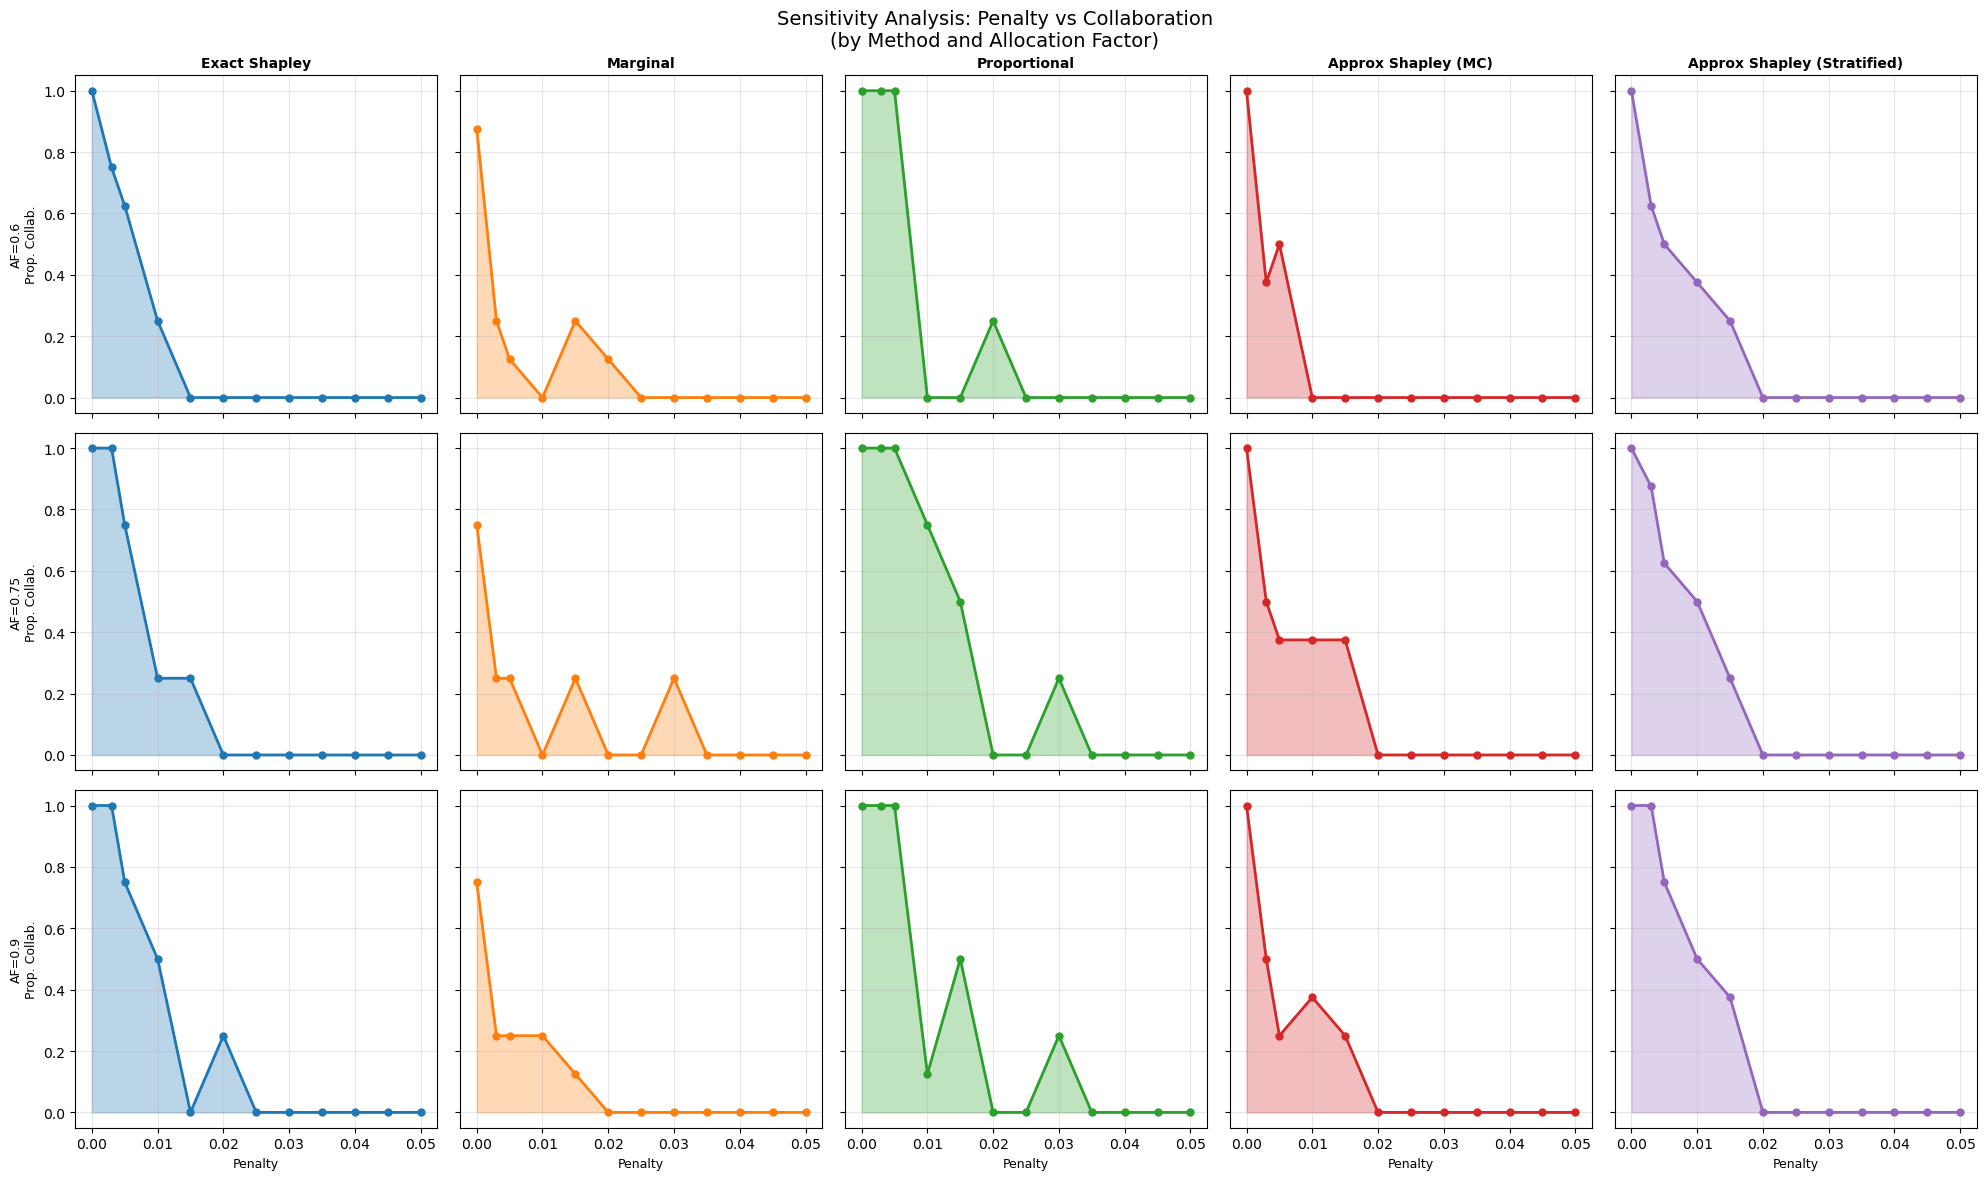

In [42]:
# Plot penalty sweep: Separate view (grid of AF x Method)
plot_penalty_sweep_separate(pen_df, output_path=None)

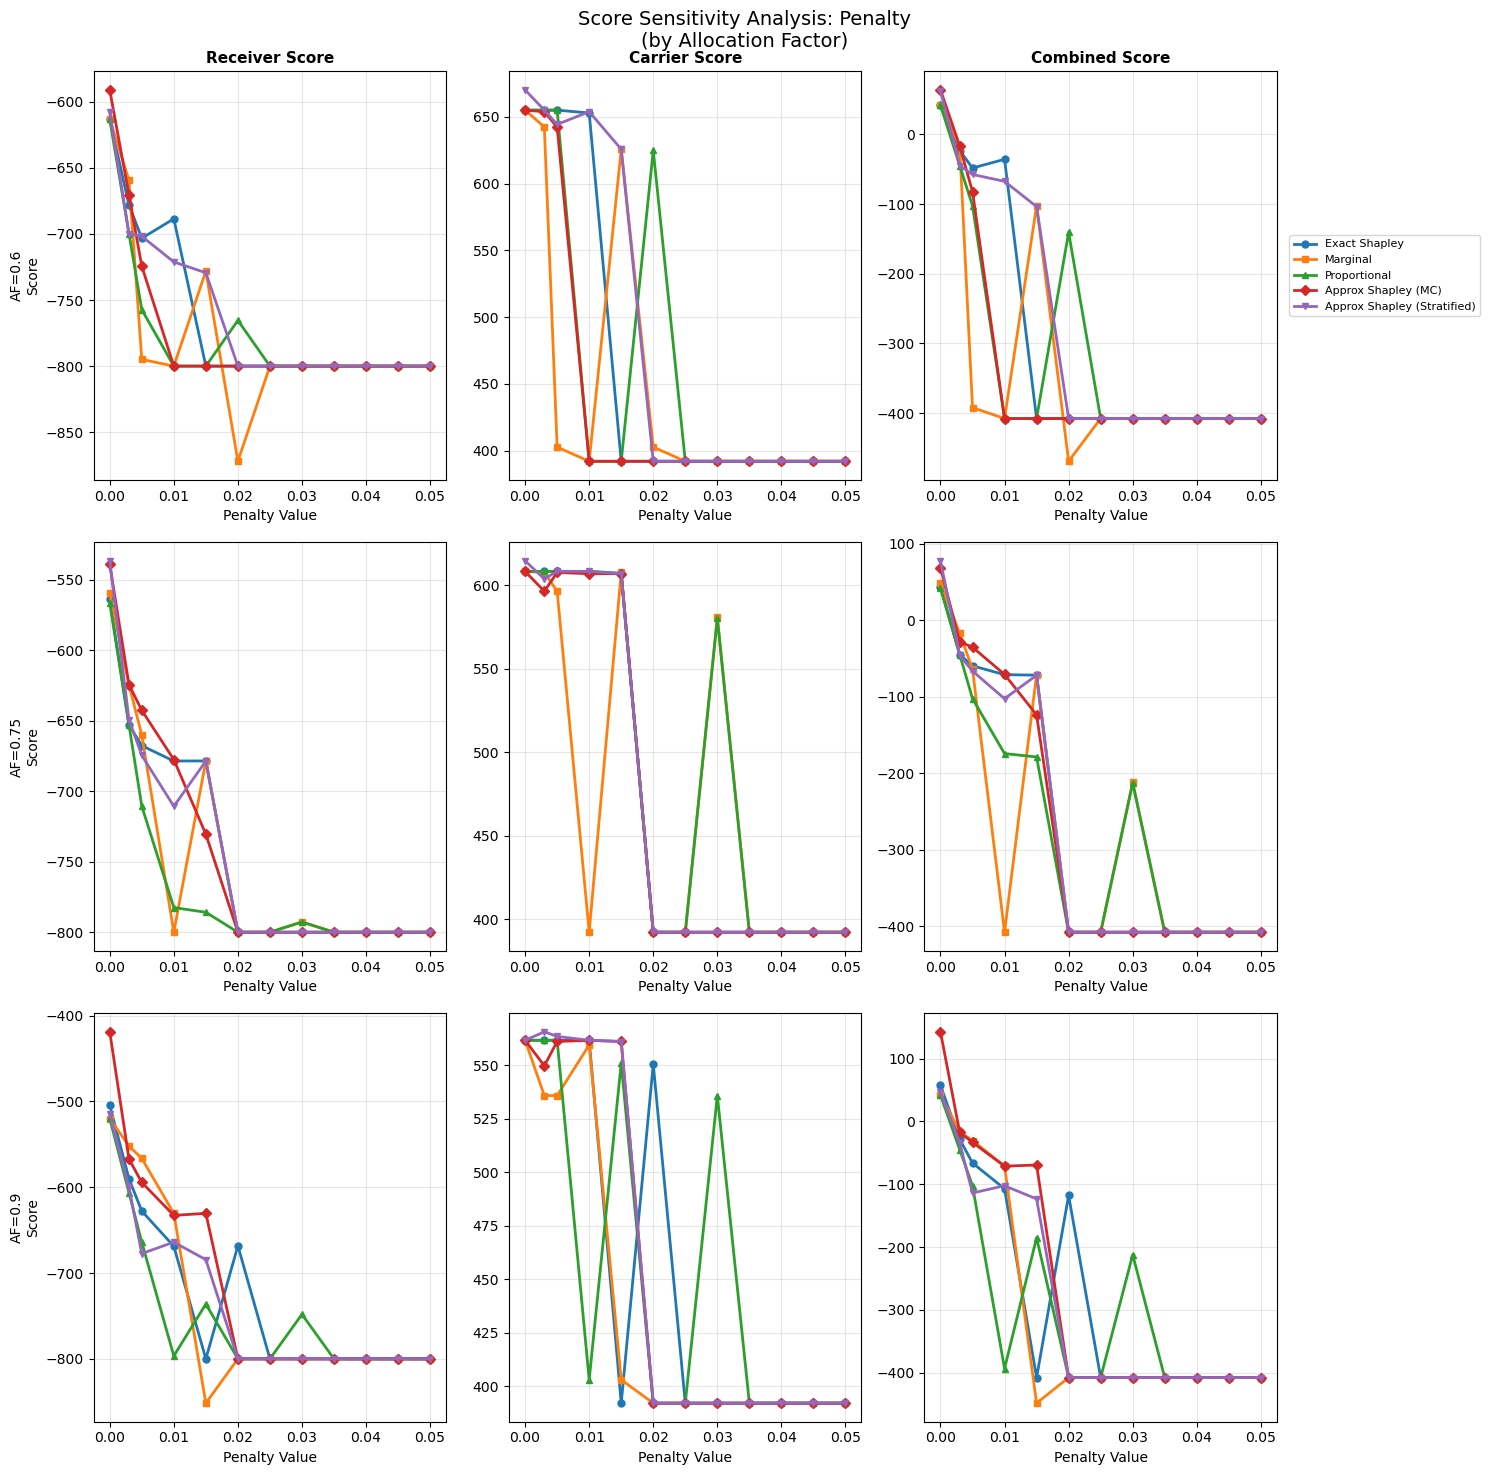

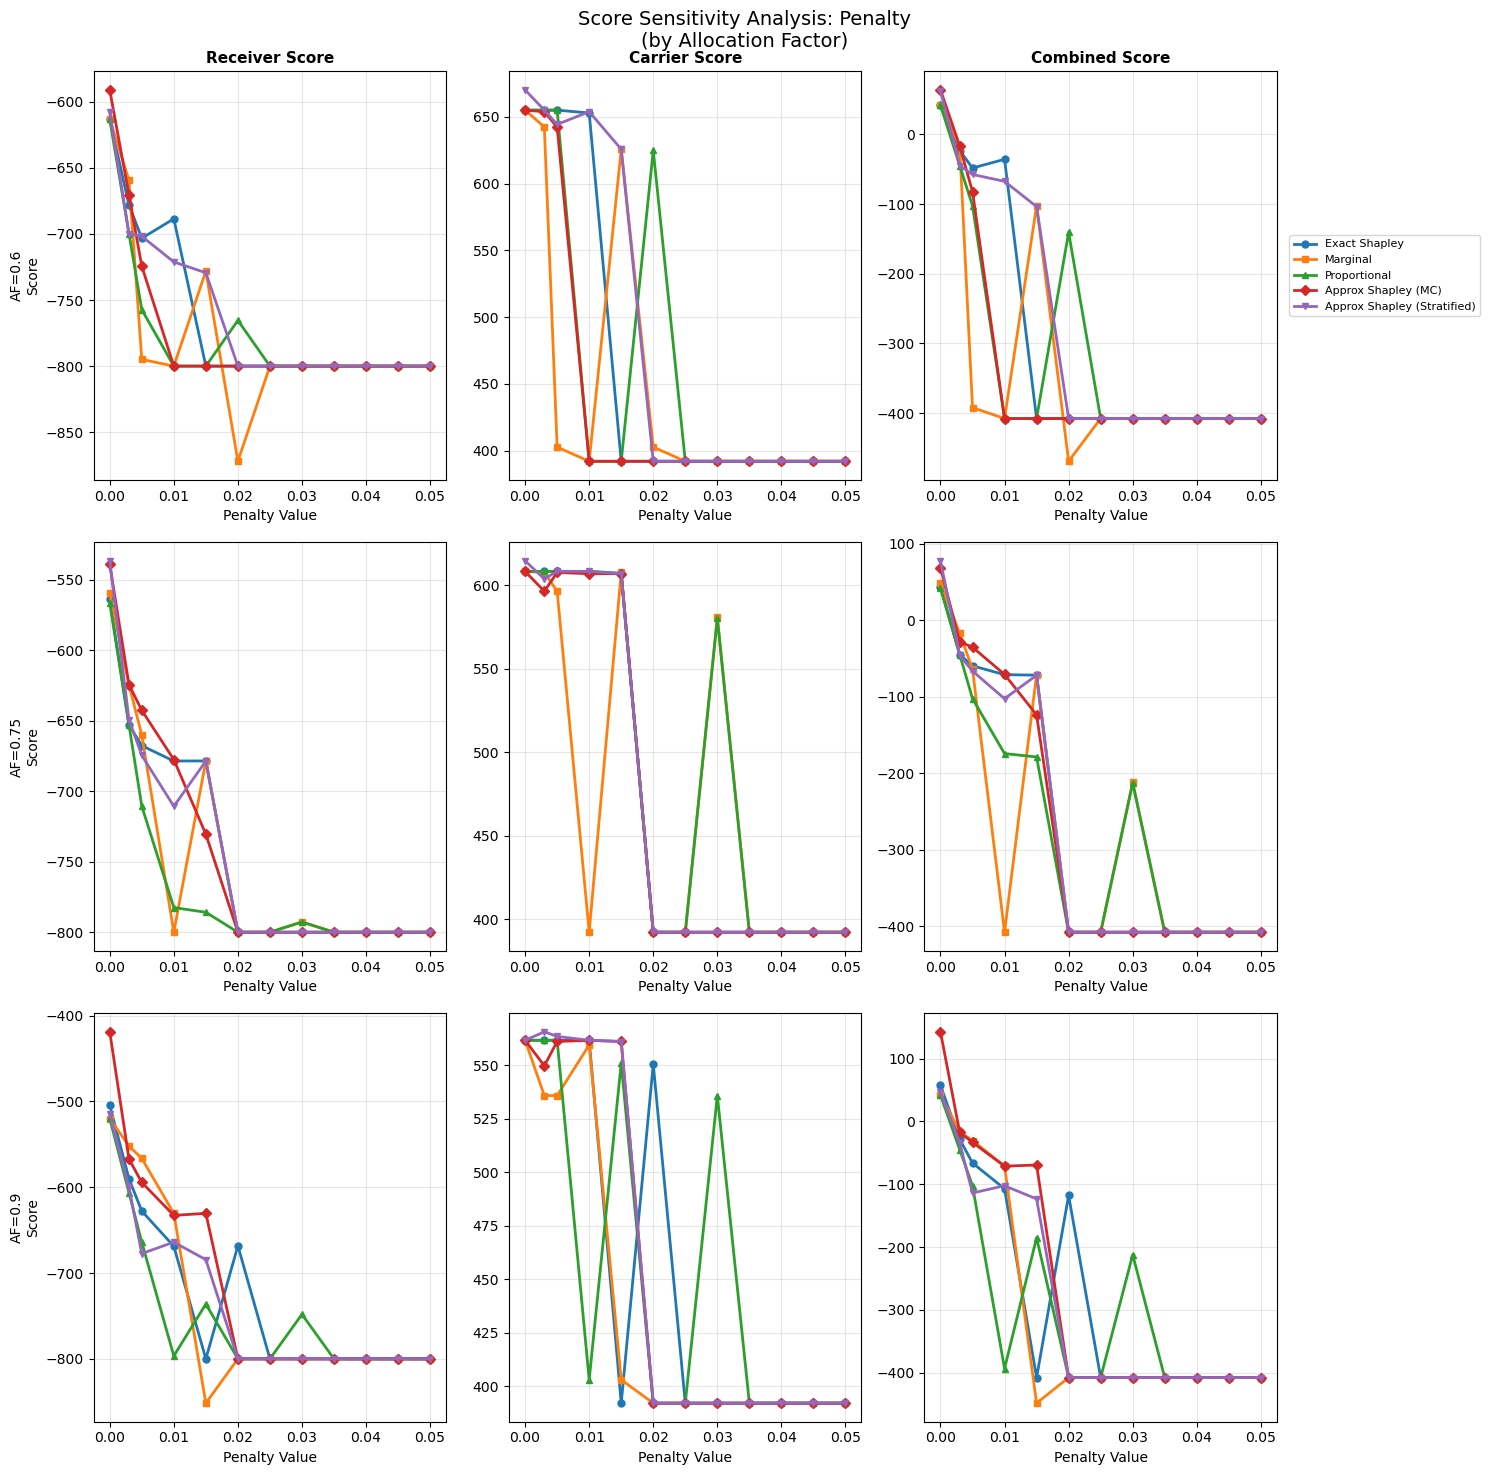

In [46]:
# Plot penalty sweep: Scores (receiver, carrier, combined) - All methods together per score type
plot_penalty_sweep_scores(pen_df, output_path=None)

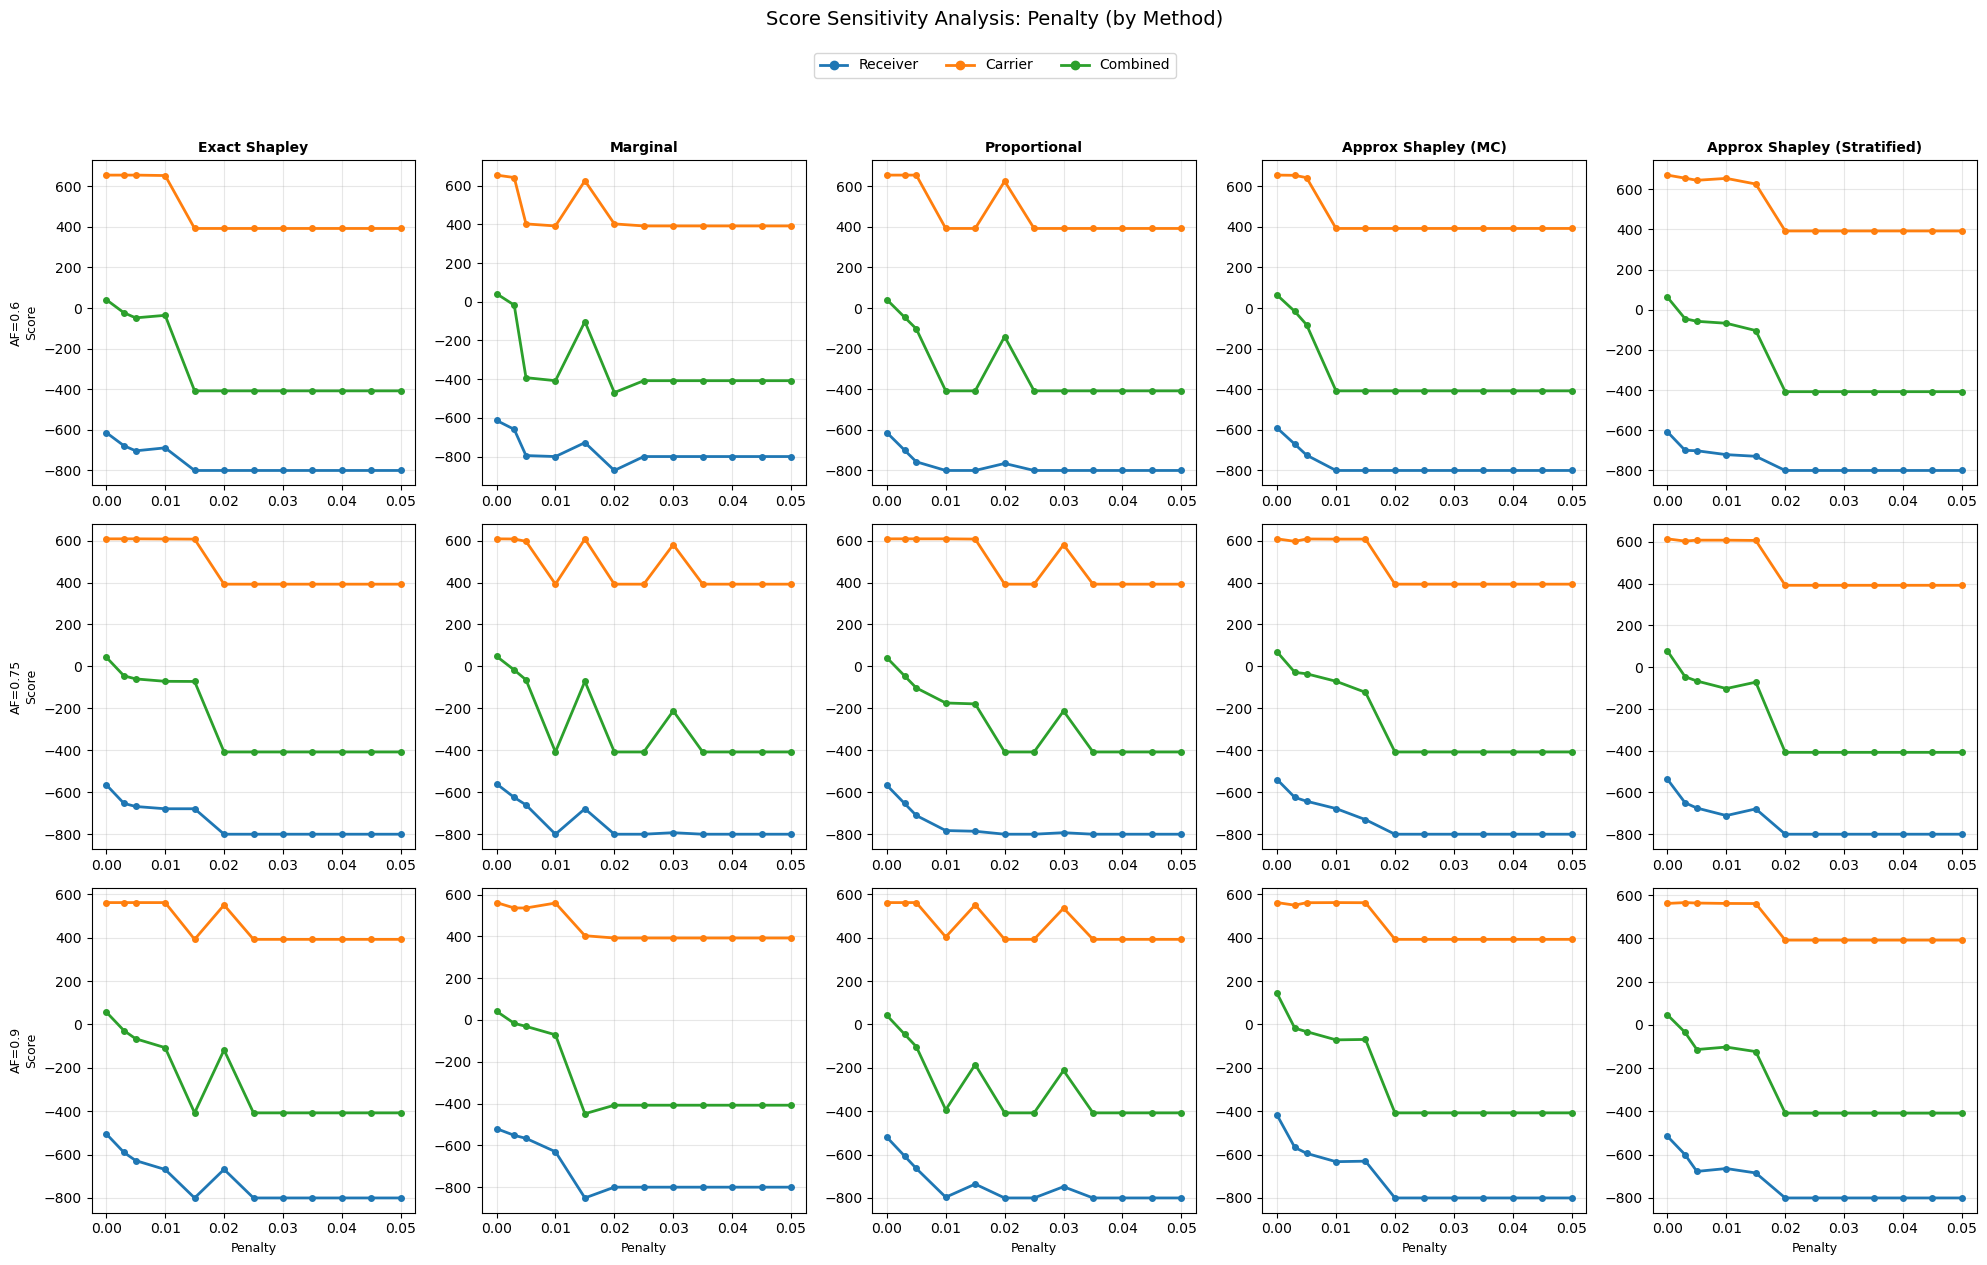

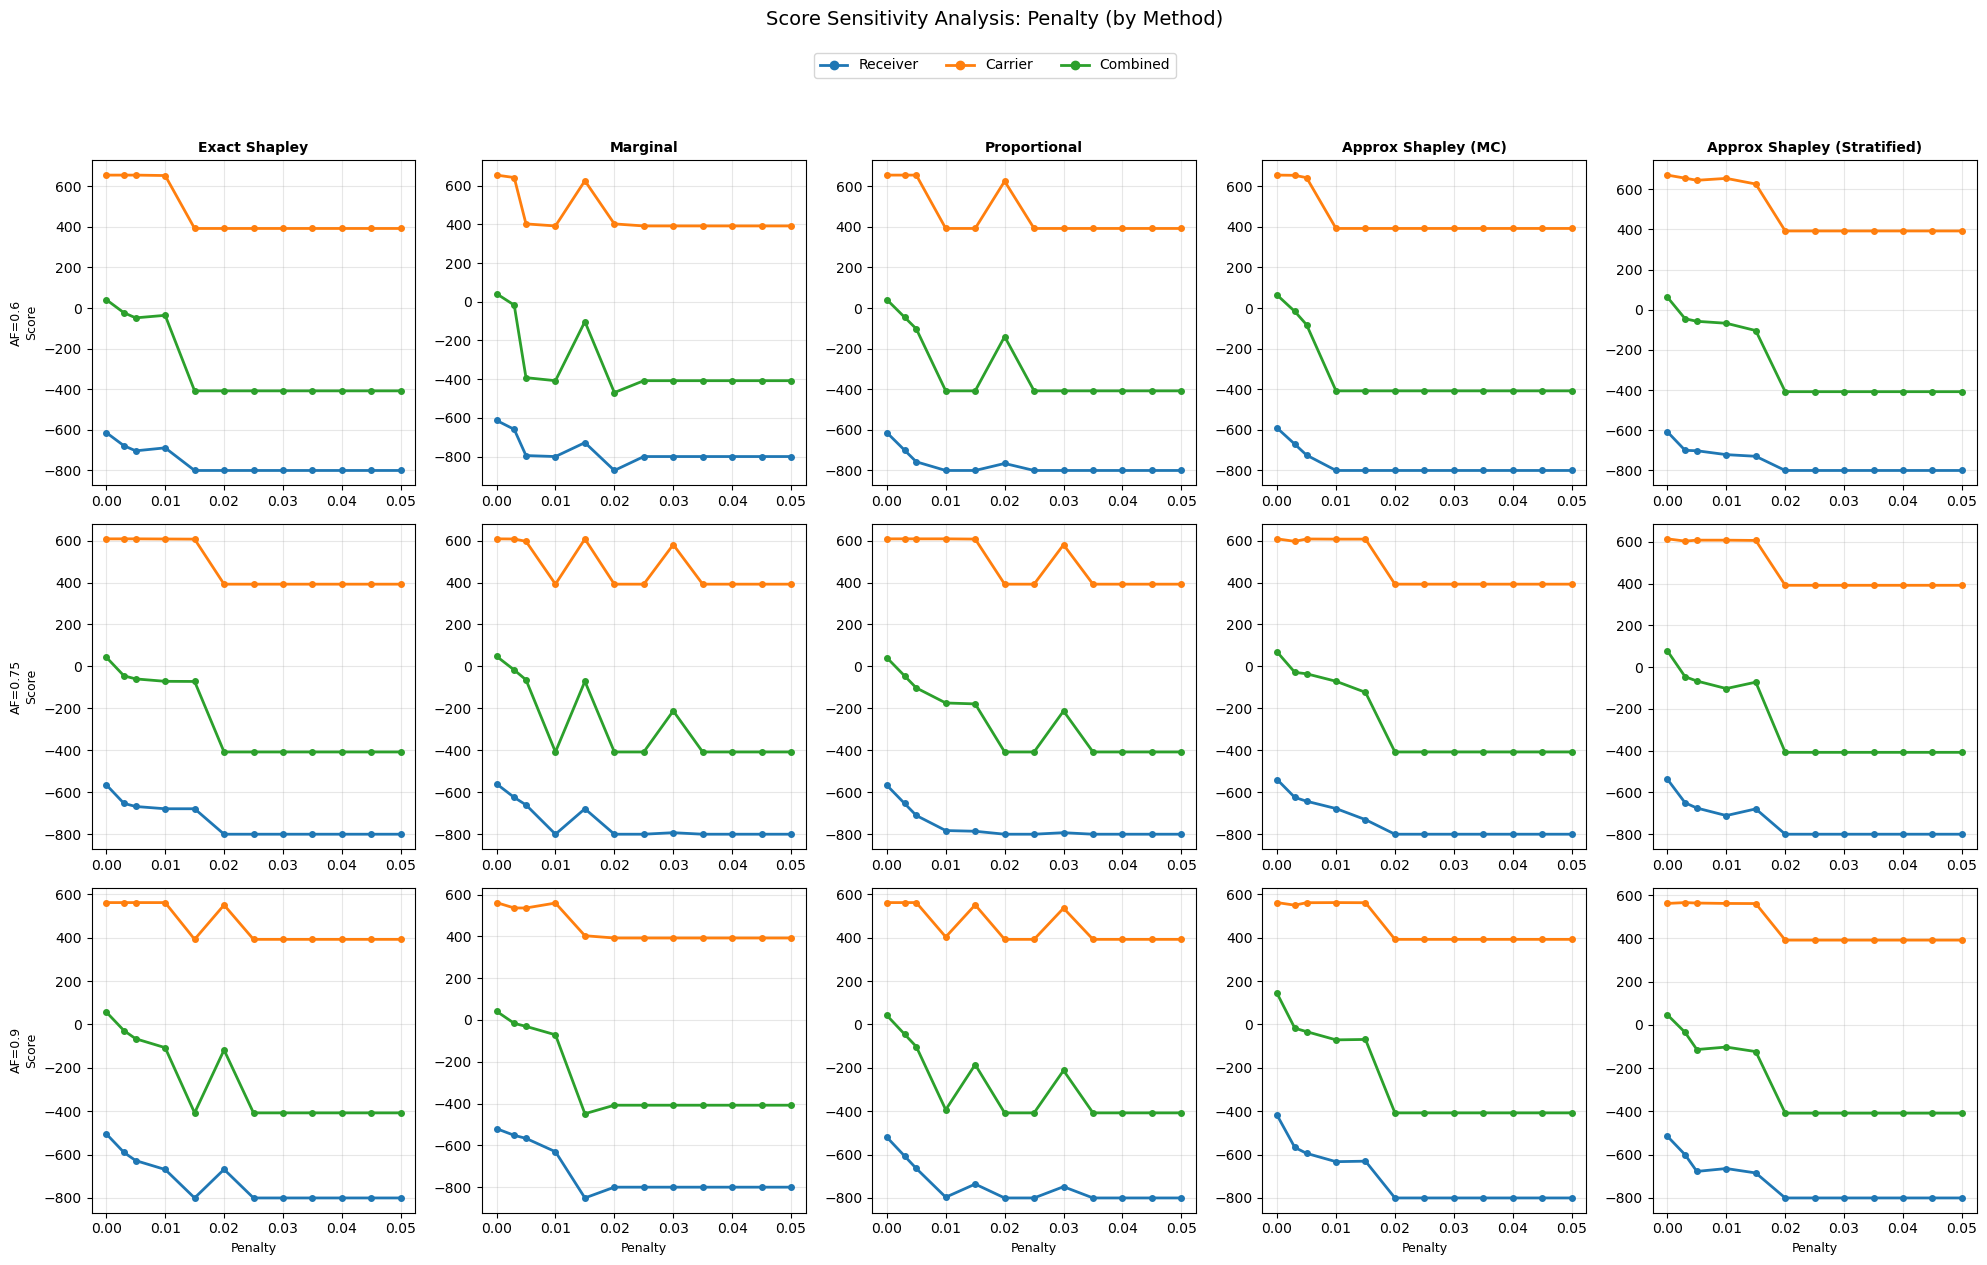

In [47]:
# Plot penalty sweep: Scores - Each method separate (grid of AF x Method)
plot_penalty_sweep_scores_separate(pen_df, output_path=None)